In [2]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo

In [3]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

## Weather Data DMI

## API ket for Climate Data

"climateDataAPI"

b555bb44-fd58-40d3-afdf-731fc7ddc5e2

In [4]:
#features

Junget is he closest Station -> to Greenlav Skive

Junget   [9.0946, 56.7637]

In [5]:
#stations_df

### Cost DataBase

In [6]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [7]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [8]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

## Load Data

In [9]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [10]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

In [11]:
DK1_data_2017.index.max()

Timestamp('2017-12-30 22:00:00')

### Adding Dynamic tariffs to Spot Price

In [12]:
DKK_Euro = 7.468  #https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-dkk.en.html
el_transmission_tariff = 4.3 / 100 * 1000 / DKK_Euro   # from energinet inputs in Ore/kWh DKK/MWh, bef 7.5
el_system_tariff = 7.2 / 100 * 1000 / DKK_Euro   # bef 5.1
el_afgift =  0.8 / 100 * 1000 / DKK_Euro         # bef 76.1 https://skm.dk/tal-og-metode/satser/satser-og-beloebsgraenser-i-lovgivningen/elafgiftsloven  https://elberegner.dk/guides/elafgift/
 
# DSO Tariff -  for 60/10kV transformer (A_low customer) #Staring from January 2026 https://n1.dk/elnetkunder/kommende-priser
el_net_tariff_low = 1.54  / 100 * 1000 / DKK_Euro   # Ore/kWh to eur/MWh
el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro
el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro

In [13]:
import pandas as pd
from types import SimpleNamespace

# ============================================================
# 1. PARAMETERS (namespace p)
# ============================================================

DKK_Euro = 7.468 

p = SimpleNamespace(

    # Model year (for defining summer/winter periods)
    En_price_year = 2017,

    # Full analysis period
    start_date = "2017-01-01",
    end_date   = "2018-01-01",

    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)


# ============================================================
# 2. PRICE CALCULATION FUNCTION
# ============================================================
def build_electricity_grid_price_w_tariff(Elspotprices):
    """
    Inputs:
        Elspotprices : pd.Series indexed by DatetimeIndex (HourUTC)
    Output:
        (final_grid_buy_price, grid_sell_price)
    """
    # ---- Base buy price (fixed tariffs only) ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # ---- Grid selling price ----
    sell_price = -Elspotprices + p.el_tariff_sell

    # Use timestamps directly from your Series
    hours = Elspotprices.index

    # ---- SUMMER ----
    summer_start = pd.Timestamp(f"{p.En_price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{p.En_price_year}-10-01 00:00", tz=hours.tz)

    summer = hours[(hours >= summer_start) & (hours < summer_end)]

    # ---- WINTER = all other hours ----
    winter = hours.difference(summer)

    # Remove Feb 29
    winter = winter[~((winter.month == 2) & (winter.day == 29))]

    # ---- Tariff rules ----
    peak_hours          = range(7, 22)     # 06–21
    high_wd_winter      = range(22, 25)    # 21–23
    high_we_winter      = range(7, 25)     # 06–23
    high_wd_summer      = range(7, 25)     # 06–23

    # ---- Tariff decision function ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour

        if h in winter:
            # WINTER
            if wd >= 5:  # weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low

        else:
            # SUMMER
            if wd >= 5:  # weekend
                return p.el_net_tariff_low
            else:
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # ---- Hourly tariff series ----
    tariffs = pd.Series({h: tariff(h) for h in hours})

    # ---- Final buy price ----
    final_price = base_price + tariffs

    return final_price, sell_price


Elspotprices = DK1_data_2017["DK1_EUR/MWh"]

# Compute grid prices
grid_buy_price, grid_sell_price = build_electricity_grid_price_w_tariff(Elspotprices)



<Axes: xlabel='HourUTC'>

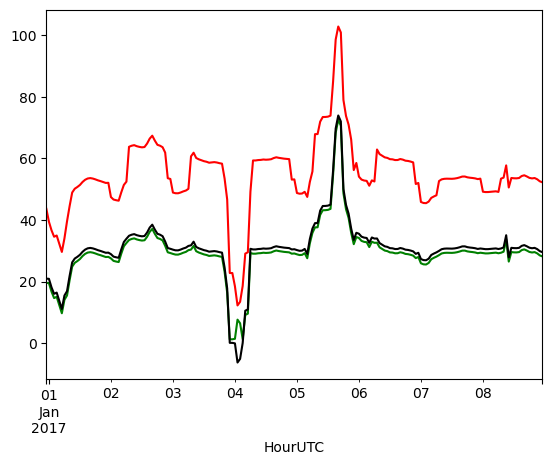

In [14]:
grid_buy_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "red")

#---- Similar Magnitudes, just the tariffs added-----------------
abs(grid_sell_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"]).plot(color = "green")
Elspotprices["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "black")


In [15]:
"Time Period in which our model is running";

hours_in_2017 = pd.date_range('2017-01-01 00:00Z',
                              '2017-12-30 22:00Z',
                              freq='h')

hours_in_2017 = hours_in_2017.tz_localize(None)

print(DK1_data_2017.index.tz)

None


In [47]:
def add_carriers():
    n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "offshorewind")
    n.add("Carrier", "nuclear")
    n.add("Carrier","solar")
    n.add("Carrier","heat")
    n.add("Carrier","heat pump")
    n.add("Carrier", "electricity")  # Add electricity carrier
    n.add("Carrier", "battery storage")  # Add battery storage carrier
    n.add("Carrier","electric boiler")
    n.add("Carrier", "hydrogen")


In [17]:
def add_skive_generators():

    n.add("Generator", "Skive_Solar", carrier="solar",
        bus ="B1" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu=solar_pv_data["DNK"].reindex(hours_in_2017).values, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "B1",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=onshore_wind_data["DNK"].reindex(hours_in_2017).values,
        p_nom = 54)

In [18]:
costs.at["battery storage", "capital_cost"]

12957.628369768725

In [19]:
def add_battery(P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="B1",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 4 h = 88 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"]
            + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # DIscharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

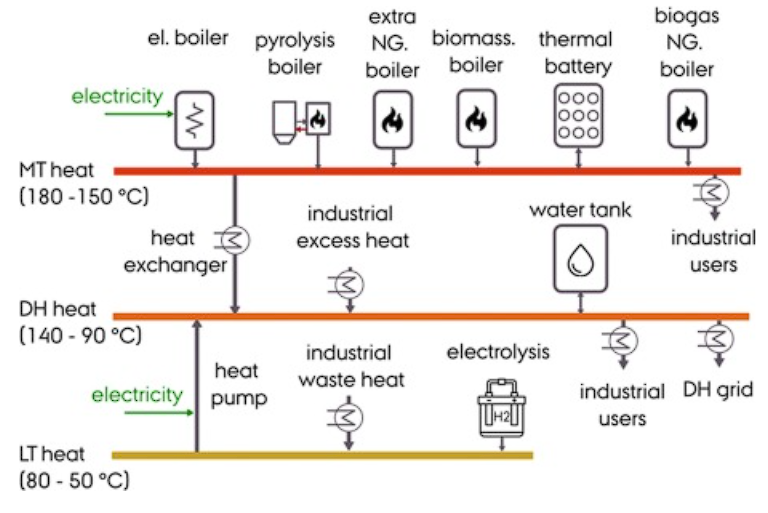

- air (RTP)
- air (400 C)
- steam (350 C) -> {turbine, heat exchnager}
- steam -> {condesner} -> hot water

- 2 seperatte links, hot water + steam (RONO) battery

- B1 -> Heat HT bus {turbine}

- natural gas boiler , add this
- pellet boiler , add this

In [20]:
import math, CoolProp.CoolProp as CP
from CoolProp.Plots import PropertyPlot

In [21]:
CP

<module 'CoolProp.CoolProp' from 'c:\\Users\\Pulin\\anaconda3\\envs\\integrated-energy-grids\\Lib\\site-packages\\CoolProp\\CoolProp.cp311-win_amd64.pyd'>

In [22]:
# Density of carbon dioxide at 100 bar and 25C
CP.PropsSI('D', 'T', 298.15, 'P', 100e5, 'CO2')

# Saturated vapor enthalpy [J/kg] of R134a at 25C
CP.PropsSI('H', 'T', 298.15, 'Q', 1, 'R134a')

412333.95323186804

In [23]:
CP.PropsSI('H', 'T', 298.15, 'P',100e5,"H2O")

114050.07555469427

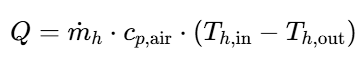

In [27]:
"High Temprature Bus (350)";
def add_TES_rondo(e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="B1",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [28]:
def add_heat_exchanger():

    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_Bus_Skive", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)


In [29]:
"Medium Temprature (150 C)";
def  add_heat_load_boiler():
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "B1",
        bus1="Heat_Bus_Skive",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Bus_Skive",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = 5) # MWh

In [30]:
tariffs = {
    "consumers": {
        "transmission_grid_tariff": 8.2,  # €/MWh
        "reduced_transmission_tariff": 7.5,
        "limited_grid_access_tariff": 3.5,
        "system_tariff": 9.9,
        "system_tariff_above_100GWh": 0.099,
        "system_subscription": 24.4  # €/year
    },
    "producers": {
        "feed_in_tariff": 0.67,  # €/MWh delivered to grid
        "balance_tariff": 0.87
    },
    "BRP": {
        "balancing_fee": 0.13,  # €/MWh imbalance
        "weekly_fee": 30  # €/week
    }
}

# Example of accessing a value
print(tariffs["consumers"]["system_tariff"])  # Output: 9.9


9.9


In [31]:
p_import = grid_buy_price.reindex(hours_in_2017).values 
#p_import = tariffs["consumers"]["transmission_grid_tariff"]
p_export = grid_sell_price.reindex(hours_in_2017).values
# p_export = tariffs["producers"]["feed_in_tariff"]

def add_grid(p_import, p_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
            bus="Grid_Import",
            p_nom_extendable = True,
            efficiency=1.0,
            marginal_cost=0,
            capital_cost=0.0)
    
    #n.add("Link", "Imports",
     #       bus0="Grid_Import",
      #      bus1="B1",
    #        p_nom = 10,
       #     p_nom_extendable=True,
        #    efficiency=0.97,
         #   p_max_pu=1.0,
          #  carrier="electricity",
           # marginal_cost=DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_import)

    n.add("Link", "Imports",
            bus0="Grid_Import",
            bus1="B1",
    #        p_nom = 10,
            p_nom_extendable=True,
            efficiency=0.97,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost= p_import
)
    

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          efficiency_store=1.0,
          carrier="electricity",
          capital_cost=0.0,
          standing_loss=0.0)

    #n.add("Link", "Exports",
     #       bus0="B1",
      #      bus1="Grid_Export",
        #   p_nom = 10, 
       #     p_nom_extendable=True,
        #    efficiency=0.97,
         #   p_min_pu=0,
          #  p_max_pu=1.0,
          #  carrier="electricity",
           # marginal_cost= -DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_export)
    
    n.add("Link", "Exports",
            bus0="B1",
            bus1="Grid_Export",
        #   p_nom = 10, 
            p_nom_extendable=True,
            efficiency=0.97,
            p_min_pu=0,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost = p_export)

In [32]:
def add_el_load(p_el = 2):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load", "Skive_el_Load", 
      bus="B1", 
      p_set= p_el) #MWh


In [35]:
costs.at["electrolysis", "efficiency"]

0.6217

In [136]:
12*costs.at["electrolysis", "efficiency"]

7.4604

In [137]:
def add_elec_H2():
    
    n.add("Link", "Electrolyzer",
    bus0="B1", bus1="Hydrogen",
    efficiency=costs.at["electrolysis", "efficiency"],  
    capital_cost=costs.at["electrolysis", "capital_cost"],
    p_nom_extendable=True,
    p_nom=12, # 12 MW
    p_min_pu = 0.15,
    p_max_pu = 1,  
    marginal_cost=0,) 

    n.add("Load", "H2_load", 
    bus="Hydrogen",
    p_set = 7.5, 
    p_nom_extendable=True)

### Simple Model

In [33]:
[p_import,p_export]

[array([39.43240493, 36.66240393, 34.56240593, ..., 27.29005892,
        27.38005892, 22.40005892]),
 array([-19.520782, -16.750781, -14.650783, ...,  -3.240782,  -3.330782,
          1.649218])]

In [138]:
n = pypsa.Network()

n.set_snapshots(hours_in_2017)

add_carriers()

n.add("Bus", "B1", carrier="electricity")
add_skive_generators()
add_battery(P_nom = 22, max_t = 4, cyclic_operation = True)

add_el_load(p_el = 2)


n.add("Bus", "Heat_Bus_Skive", carrier="heat")
add_heat_load_boiler()

n.add("Bus", "TES_Rondo", carrier="heat")
n.add("Bus", "Heat_Exchanger_Bus" ,carrier="heat")

add_TES_rondo(e_nom_store = 100, p_nom_charge = 20,p_nom_discharge = 7)


add_heat_exchanger()


n.add("Bus", "Hydrogen", carrier="hydrogen")
add_elec_H2()


n.add("Bus","Grid_Import", carrier = "electricity")
n.add("Bus","Grid_Export", carrier = "electricity")

add_grid(p_import = p_import ,p_export = p_export)
#add_grid(p_import = 0 ,p_export = 0)

In [104]:
n.consistency_check()

In [94]:
# Check for missing buses
print("=== Buses ===")
print(n.buses.index.tolist())

print("\n=== Links (bus0 -> bus1) ===")
print(n.links[["bus0", "bus1"]])

print("\n=== Generators (bus) ===")
print(n.generators[["bus"]])

print("\n=== Loads (bus) ===")
print(n.loads[["bus"]])

print("\n=== Storage Units (bus) ===")
print(n.storage_units[["bus"]])

# Check for NaN in time-series
print("\n=== NaN counts in time series ===")
for col in n.generators_t.p_max_pu.columns:
    nan_count = n.generators_t.p_max_pu[col].isna().sum()
    if nan_count > 0:
        print(f"  {col}: {nan_count} NaN values")

print("\n=== Running consistency check ===")
n.consistency_check()

=== Buses ===
['B1', 'Heat_Bus_Skive', 'TES_Rondo', 'Heat_Exchanger_Bus', 'Hydrogen', 'Grid_Import', 'Grid_Export']

=== Links (bus0 -> bus1) ===
                                           bus0                bus1
Link                                                               
Boiler_Skive                                 B1      Heat_Bus_Skive
El_to_TES_Rondo                              B1           TES_Rondo
TES_Rondo_to_Heat_Bus_Skive           TES_Rondo  Heat_Exchanger_Bus
Heat_Exchanger_Rondo         Heat_Exchanger_Bus      Heat_Bus_Skive
Electrolyzer                                 B1            Hydrogen
Imports                             Grid_Import                  B1
Exports                                      B1         Grid_Export

=== Generators (bus) ===
                            bus
Generator                      
Skive_Solar                  B1
Skive_Onshore_Wind           B1
Grid_Generator      Grid_Import

=== Loads (bus) ===
                            bus
Loa

In [105]:
model = n.copy()

In [139]:
n.optimize(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 19.39it/s]
INFO:linopy.io: Writing time: 3.92s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

Solved in 43600 iterations and 3.43 seconds (0.60 work units)


INFO:gurobipy:Solved in 43600 iterations and 3.43 seconds (0.60 work units)


Optimal objective  1.738134579e+06


INFO:gurobipy:Optimal objective  1.738134579e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 148502 primals, 349406 duals
Objective: 1.74e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

In [34]:
## Rolling Horizon
n_rh24_0 = model.copy()
n_rh24_0.optimize.optimize_with_rolling_horizon(horizon=24, overlap=0,log_to_console=False)

INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2017-01-01 00:00:00:2017-01-01 23:00:00] (1/364).
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 364 primals, 820 duals
Objective: -3.41e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energ

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 5
 - Carrier: 10
 - Generator: 3
 - Link: 5
 - Load: 2
 - StorageUnit: 1
 - Store: 2
Snapshots: 8735

<Axes: xlabel='snapshot'>

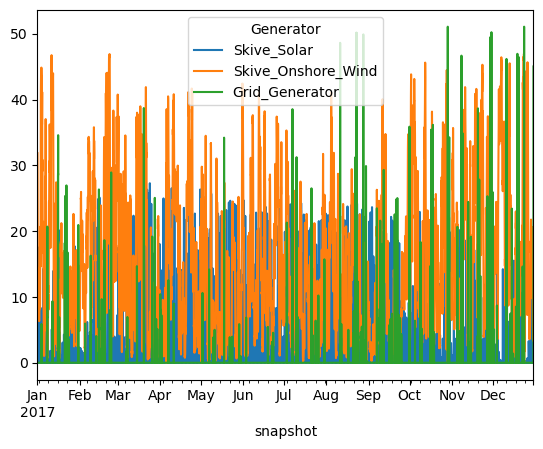

In [35]:
n_rh24_0.generators_t.p.plot()

In [36]:
[n.objective/1e6,n_rh24_0.objective/1e6] # MEUR

[-2.4125370356610287, -0.0020408738311514765]

In [37]:
n.objective/n_rh24_0.objective

1182.1098388526334

In [141]:
n.statistics.optimal_capacity()

component    carrier        
Generator    -                     63.52500
             onshorewind           54.00000
             solar                 36.00000
Link         electric boiler       10.00000
             electricity          152.35900
             heat                  13.25000
StorageUnit  battery storage       22.00000
Store        electricity        24368.86389
             heat                 100.00000
dtype: float64

In [39]:
n_rh24_0.statistics.optimal_capacity()

component    carrier        
Generator    -                     45.04710
             onshorewind           54.00000
             solar                 36.00000
Link         electric boiler       10.00000
             electricity           80.46829
             heat                   7.00000
StorageUnit  battery storage       22.00000
Store        electricity        87343.63620
             heat                 100.00000
dtype: float64

In [140]:
n.statistics.curtailment().div(1e6)

component    carrier        
Generator    -                  0.507832
             onshorewind        0.001464
StorageUnit  battery storage    0.195587
dtype: float64

In [41]:
n_rh24_0.statistics.curtailment().div(1e6)

component    carrier        
Generator    -                  0.388525
             onshorewind        0.002799
StorageUnit  battery storage    0.195602
dtype: float64

NameError: name 'n_rh24_0' is not defined

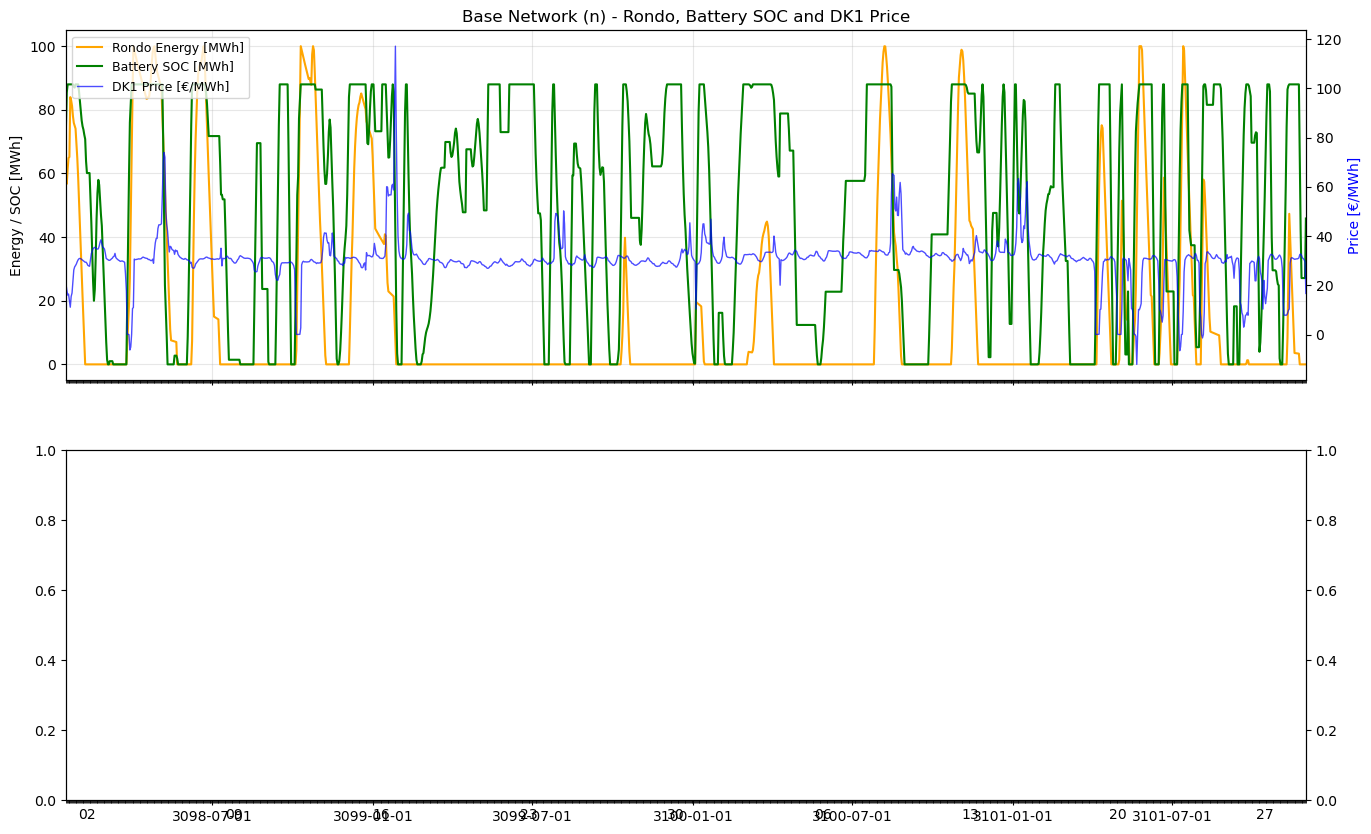

In [99]:
# ...existing code...
import matplotlib.dates as mdates

def plot_storage_comparison(ax, ax2, network, start_date, end_date, title):
    """Helper function to plot Rondo, Battery SOC, and DK1 Price"""
    # Plot on left axis (Energy/SOC)
    network.stores_t.e['Rondo_Concrete_Heat_Storage'].loc[start_date:end_date].plot(
        ax=ax, color="orange", linewidth=1.5, label="Rondo Energy [MWh]"
    )
    network.storage_units_t.state_of_charge["Skive_Battery"].loc[start_date:end_date].plot(
        ax=ax, color="green", linewidth=1.5, label="Battery SOC [MWh]"
    )
    
    # Plot on right axis (Price)
    DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).loc[start_date:end_date].plot(
        ax=ax2, color="blue", linewidth=1, alpha=0.7, label="DK1 Price [€/MWh]"
    )
    
    # Configure axes
    ax.set_ylabel("Energy / SOC [MWh]", color="k")
    ax2.set_ylabel("Price [€/MWh]", color="blue")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)


# Define time frame
start_date = "2017-01-01"
end_date = "2017-02-28"

# Create figure with subplots for comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Base Network (n) ---
ax = axes[0]
ax2_base = ax.twinx()
plot_storage_comparison(ax, ax2_base, n, start_date, end_date, 
                       "Base Network (n) - Rondo, Battery SOC and DK1 Price")

# --- Rolling Horizon Network (n_rh24_0) ---
ax = axes[1]
ax2_rh = ax.twinx()
plot_storage_comparison(ax, ax2_rh, n_rh24_0, start_date, end_date,
                       "Rolling Horizon (n_rh24_0) - Rondo, Battery SOC and DK1 Price")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()
# ...existing code...

BATTERY CHARGING/DISCHARGING FREQUENCY COMPARISON

Threshold for 'active' operation: 0.1 MW

BASE NETWORK (n):
  Charging active hours:         1720 h ( 19.7%)
  Discharging active hours:      1621 h ( 18.6%)
  Total active hours:            3341 h ( 19.1%)
  Average charging power:         2.30 MW
  Average discharging power:      1.99 MW
  Max charging power:            22.00 MW
  Max discharging power:         22.00 MW

ROLLING HORIZON (n_rh24_0):
  Charging active hours:         2017 h ( 23.1%)
  Discharging active hours:      1788 h ( 20.5%)
  Total active hours:            3805 h ( 21.8%)
  Average charging power:         2.89 MW
  Average discharging power:      2.50 MW
  Max charging power:            22.00 MW
  Max discharging power:         22.00 MW

DIFFERENCES:
  Δ Charging active hours:       +297 h
  Δ Discharging active hours:    +167 h
  Δ Total active hours:          +464 h


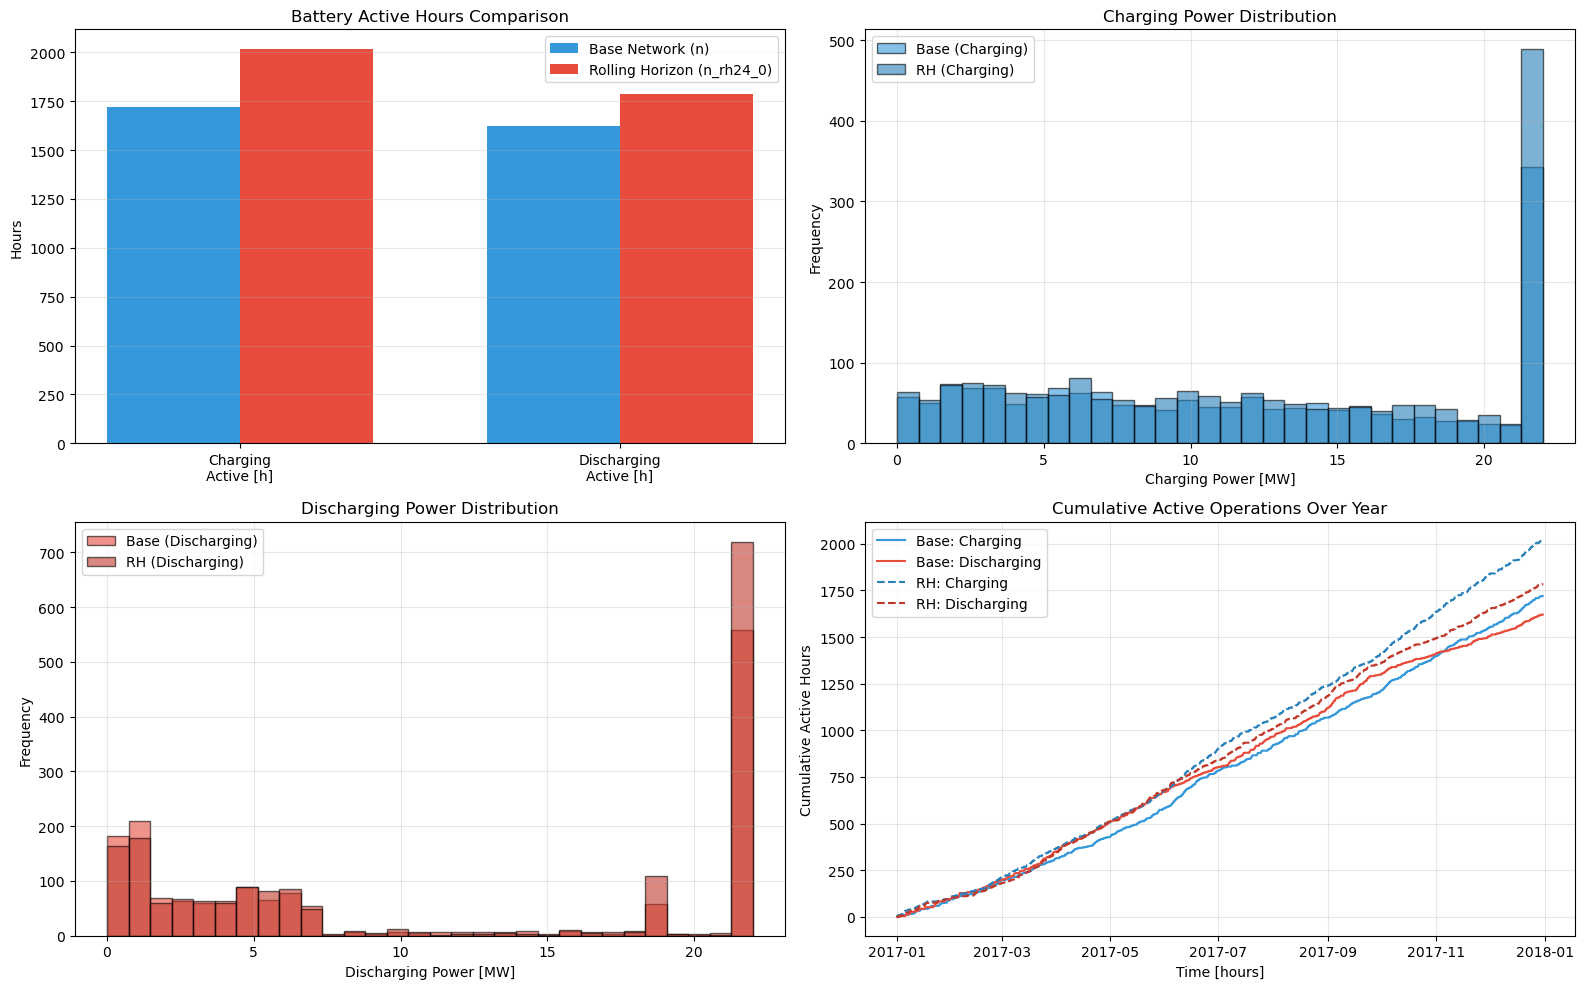

In [43]:
# Compare charging/discharging frequency between base network and rolling horizon

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define threshold for "active" charging/discharging (MW)
threshold = 0.1

# --- Base Network (n) ---
base_charge = n.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n.snapshots))
base_discharge = n.storage_units_t.p_dispatch.get("Skive_Battery", pd.Series(0, index=n.snapshots))

# Count active charging/discharging periods
base_charge_active = (base_charge > threshold).sum()
base_discharge_active = (base_discharge > threshold).sum()
base_total_active = base_charge_active + base_discharge_active

# --- Rolling Horizon Network (n_rh24_0) ---
rh_charge = n_rh24_0.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n_rh24_0.snapshots))
rh_discharge = n_rh24_0.storage_units_t.p_dispatch.get("Skive_Battery", pd.Series(0, index=n_rh24_0.snapshots))

# Count active charging/discharging periods
rh_charge_active = (rh_charge > threshold).sum()
rh_discharge_active = (rh_discharge > threshold).sum()
rh_total_active = rh_charge_active + rh_discharge_active

# Print statistics
print("=" * 60)
print("BATTERY CHARGING/DISCHARGING FREQUENCY COMPARISON")
print("=" * 60)
print(f"\nThreshold for 'active' operation: {threshold} MW\n")

print("BASE NETWORK (n):")
print(f"  Charging active hours:        {base_charge_active:5d} h ({100*base_charge_active/len(base_charge):5.1f}%)")
print(f"  Discharging active hours:     {base_discharge_active:5d} h ({100*base_discharge_active/len(base_discharge):5.1f}%)")
print(f"  Total active hours:           {base_total_active:5d} h ({100*base_total_active/(2*len(base_charge)):5.1f}%)")
print(f"  Average charging power:       {base_charge.mean():6.2f} MW")
print(f"  Average discharging power:    {base_discharge.mean():6.2f} MW")
print(f"  Max charging power:           {base_charge.max():6.2f} MW")
print(f"  Max discharging power:        {base_discharge.max():6.2f} MW")

print("\nROLLING HORIZON (n_rh24_0):")
print(f"  Charging active hours:        {rh_charge_active:5d} h ({100*rh_charge_active/len(rh_charge):5.1f}%)")
print(f"  Discharging active hours:     {rh_discharge_active:5d} h ({100*rh_discharge_active/len(rh_discharge):5.1f}%)")
print(f"  Total active hours:           {rh_total_active:5d} h ({100*rh_total_active/(2*len(rh_charge)):5.1f}%)")
print(f"  Average charging power:       {rh_charge.mean():6.2f} MW")
print(f"  Average discharging power:    {rh_discharge.mean():6.2f} MW")
print(f"  Max charging power:           {rh_charge.max():6.2f} MW")
print(f"  Max discharging power:        {rh_discharge.max():6.2f} MW")

print("\nDIFFERENCES:")
print(f"  Δ Charging active hours:      {rh_charge_active - base_charge_active:+5d} h")
print(f"  Δ Discharging active hours:   {rh_discharge_active - base_discharge_active:+5d} h")
print(f"  Δ Total active hours:         {rh_total_active - base_total_active:+5d} h")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Charging/Discharging Comparison (Bar Chart)
ax = axes[0, 0]
categories = ["Charging\nActive [h]", "Discharging\nActive [h]"]
base_vals = [base_charge_active, base_discharge_active]
rh_vals = [rh_charge_active, rh_discharge_active]

x = np.arange(len(categories))
width = 0.35

ax.bar(x - width/2, base_vals, width, label="Base Network (n)", color="#3498db")
ax.bar(x + width/2, rh_vals, width, label="Rolling Horizon (n_rh24_0)", color="#e74c3c")
ax.set_ylabel("Hours")
ax.set_title("Battery Active Hours Comparison")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Plot 2: Power Distribution (Histograms)
ax = axes[0, 1]
ax.hist(base_charge[base_charge > 0], bins=30, alpha=0.6, label="Base (Charging)", color="#3498db", edgecolor="black")
ax.hist(rh_charge[rh_charge > 0], bins=30, alpha=0.6, label="RH (Charging)", color="#2980b9", edgecolor="black")
ax.set_xlabel("Charging Power [MW]")
ax.set_ylabel("Frequency")
ax.set_title("Charging Power Distribution")
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Discharging Power Distribution
ax = axes[1, 0]
ax.hist(base_discharge[base_discharge > 0], bins=30, alpha=0.6, label="Base (Discharging)", color="#e74c3c", edgecolor="black")
ax.hist(rh_discharge[rh_discharge > 0], bins=30, alpha=0.6, label="RH (Discharging)", color="#c0392b", edgecolor="black")
ax.set_xlabel("Discharging Power [MW]")
ax.set_ylabel("Frequency")
ax.set_title("Discharging Power Distribution")
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Cumulative Active Time
ax = axes[1, 1]
base_cumsum_charge = (base_charge > threshold).astype(int).cumsum()
base_cumsum_discharge = (base_discharge > threshold).astype(int).cumsum()
rh_cumsum_charge = (rh_charge > threshold).astype(int).cumsum()
rh_cumsum_discharge = (rh_discharge > threshold).astype(int).cumsum()

ax.plot(base_cumsum_charge, label="Base: Charging", color="#3498db", linewidth=1.5)
ax.plot(base_cumsum_discharge, label="Base: Discharging", color="#e74c3c", linewidth=1.5)
ax.plot(rh_cumsum_charge, label="RH: Charging", color="#2980b9", linewidth=1.5, linestyle="--")
ax.plot(rh_cumsum_discharge, label="RH: Discharging", color="#c0392b", linewidth=1.5, linestyle="--")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Cumulative Active Hours")
ax.set_title("Cumulative Active Operations Over Year")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

BATTERY OPERATION & STANDBY HOURS COMPARISON

Threshold for 'active' operation: 0.1 MW

BASE NETWORK (n):
  Charging active hours:         1720 h ( 19.7%)
  Discharging active hours:      1621 h ( 18.6%)
  Total active hours:            3341 h ( 38.2%)
  STANDBY hours (idle):          5394 h ( 61.8%)
  Average charging power:         2.30 MW
  Average discharging power:      1.99 MW
  Max charging power:            22.00 MW
  Max discharging power:         22.00 MW
  Average SOC:                   46.73 MWh

ROLLING HORIZON (n_rh24_0):
  Charging active hours:         2017 h ( 23.1%)
  Discharging active hours:      1788 h ( 20.5%)
  Total active hours:            3805 h ( 43.6%)
  STANDBY hours (idle):          4930 h ( 56.4%)
  Average charging power:         2.89 MW
  Average discharging power:      2.50 MW
  Max charging power:            22.00 MW
  Max discharging power:         22.00 MW
  Average SOC:                   30.08 MWh

DIFFERENCES:
  Δ Charging active hours:       +297

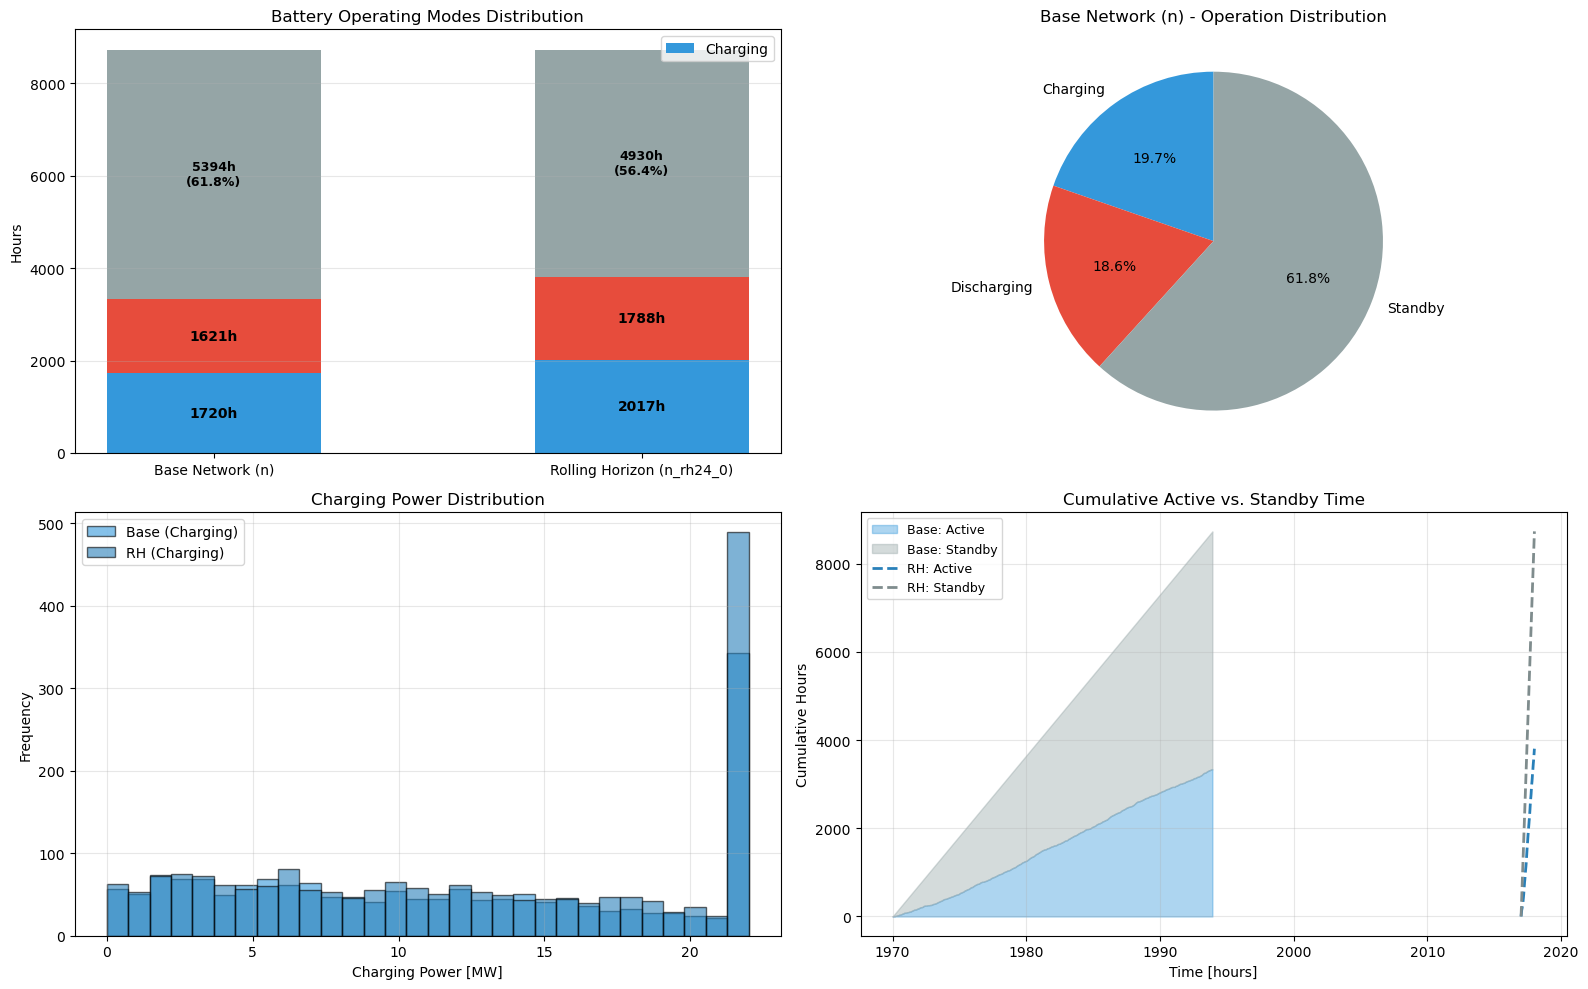

In [44]:
# Compare charging/discharging frequency AND standby hours

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define threshold for "active" charging/discharging (MW)
threshold = 0.1

# --- Base Network (n) ---
base_charge = n.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n.snapshots))
base_discharge = n.storage_units_t.p_dispatch.get("Skive_Battery", pd.Series(0, index=n.snapshots))
base_soc = n.storage_units_t.state_of_charge.get("Skive_Battery", pd.Series(0, index=n.snapshots))

# Count active charging/discharging periods
base_charge_active = (base_charge > threshold).sum()
base_discharge_active = (base_discharge > threshold).sum()
base_total_active = base_charge_active + base_discharge_active
base_standby = len(base_charge) - base_total_active  # Hours when battery is idle

# --- Rolling Horizon Network (n_rh24_0) ---
rh_charge = n_rh24_0.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n_rh24_0.snapshots))
rh_discharge = n_rh24_0.storage_units_t.p_dispatch.get("Skive_Battery", pd.Series(0, index=n_rh24_0.snapshots))
rh_soc = n_rh24_0.storage_units_t.state_of_charge.get("Skive_Battery", pd.Series(0, index=n_rh24_0.snapshots))

# Count active charging/discharging periods
rh_charge_active = (rh_charge > threshold).sum()
rh_discharge_active = (rh_discharge > threshold).sum()
rh_total_active = rh_charge_active + rh_discharge_active
rh_standby = len(rh_charge) - rh_total_active  # Hours when battery is idle

# Print statistics
print("=" * 70)
print("BATTERY OPERATION & STANDBY HOURS COMPARISON")
print("=" * 70)
print(f"\nThreshold for 'active' operation: {threshold} MW\n")

print("BASE NETWORK (n):")
print(f"  Charging active hours:        {base_charge_active:5d} h ({100*base_charge_active/len(base_charge):5.1f}%)")
print(f"  Discharging active hours:     {base_discharge_active:5d} h ({100*base_discharge_active/len(base_discharge):5.1f}%)")
print(f"  Total active hours:           {base_total_active:5d} h ({100*base_total_active/len(base_charge):5.1f}%)")
print(f"  STANDBY hours (idle):         {base_standby:5d} h ({100*base_standby/len(base_charge):5.1f}%)")
print(f"  Average charging power:       {base_charge.mean():6.2f} MW")
print(f"  Average discharging power:    {base_discharge.mean():6.2f} MW")
print(f"  Max charging power:           {base_charge.max():6.2f} MW")
print(f"  Max discharging power:        {base_discharge.max():6.2f} MW")
print(f"  Average SOC:                  {base_soc.mean():6.2f} MWh")

print("\nROLLING HORIZON (n_rh24_0):")
print(f"  Charging active hours:        {rh_charge_active:5d} h ({100*rh_charge_active/len(rh_charge):5.1f}%)")
print(f"  Discharging active hours:     {rh_discharge_active:5d} h ({100*rh_discharge_active/len(rh_discharge):5.1f}%)")
print(f"  Total active hours:           {rh_total_active:5d} h ({100*rh_total_active/len(rh_charge):5.1f}%)")
print(f"  STANDBY hours (idle):         {rh_standby:5d} h ({100*rh_standby/len(rh_charge):5.1f}%)")
print(f"  Average charging power:       {rh_charge.mean():6.2f} MW")
print(f"  Average discharging power:    {rh_discharge.mean():6.2f} MW")
print(f"  Max charging power:           {rh_charge.max():6.2f} MW")
print(f"  Max discharging power:        {rh_discharge.max():6.2f} MW")
print(f"  Average SOC:                  {rh_soc.mean():6.2f} MWh")

print("\nDIFFERENCES:")
print(f"  Δ Charging active hours:      {rh_charge_active - base_charge_active:+5d} h")
print(f"  Δ Discharging active hours:   {rh_discharge_active - base_discharge_active:+5d} h")
print(f"  Δ Total active hours:         {rh_total_active - base_total_active:+5d} h")
print(f"  Δ Standby hours:              {rh_standby - base_standby:+5d} h")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Operating Mode Distribution (Stacked Bar)
ax = axes[0, 0]
modes = ["Charging", "Discharging", "Standby"]
base_vals = [base_charge_active, base_discharge_active, base_standby]
rh_vals = [rh_charge_active, rh_discharge_active, rh_standby]

x = np.arange(len(["Base Network", "Rolling Horizon"]))
width = 0.5

# Create stacked bars
bottom_base = 0
bottom_rh = 0
colors = ["#3498db", "#e74c3c", "#95a5a6"]

for i, (mode, color) in enumerate(zip(modes, colors)):
    ax.bar(0, base_vals[i], width, bottom=bottom_base, label=mode if i == 0 else "", color=color)
    ax.bar(1, rh_vals[i], width, bottom=bottom_rh, color=color)
    if i == 0:
        ax.text(0, bottom_base + base_vals[i]/2, f"{base_vals[i]}h", ha="center", va="center", fontweight="bold")
        ax.text(1, bottom_rh + rh_vals[i]/2, f"{rh_vals[i]}h", ha="center", va="center", fontweight="bold")
    elif i == 1:
        ax.text(0, bottom_base + base_vals[i]/2, f"{base_vals[i]}h", ha="center", va="center", fontweight="bold")
        ax.text(1, bottom_rh + rh_vals[i]/2, f"{rh_vals[i]}h", ha="center", va="center", fontweight="bold")
    else:
        ax.text(0, bottom_base + base_vals[i]/2, f"{base_vals[i]}h\n({100*base_vals[i]/len(base_charge):.1f}%)", 
                ha="center", va="center", fontweight="bold", fontsize=9)
        ax.text(1, bottom_rh + rh_vals[i]/2, f"{rh_vals[i]}h\n({100*rh_vals[i]/len(rh_charge):.1f}%)", 
                ha="center", va="center", fontweight="bold", fontsize=9)
    bottom_base += base_vals[i]
    bottom_rh += rh_vals[i]

ax.set_ylabel("Hours")
ax.set_title("Battery Operating Modes Distribution")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Base Network (n)", "Rolling Horizon (n_rh24_0)"])
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

# Plot 2: Pie Charts Comparison
ax1 = plt.subplot(2, 2, 2)
base_data = [base_charge_active, base_discharge_active, base_standby]
colors_pie = ["#3498db", "#e74c3c", "#95a5a6"]
ax1.pie(base_data, labels=modes, autopct="%1.1f%%", colors=colors_pie, startangle=90)
ax1.set_title("Base Network (n) - Operation Distribution")

# Plot 3: Power Distribution (Histograms)
ax = axes[1, 0]
ax.hist(base_charge[base_charge > 0], bins=30, alpha=0.6, label="Base (Charging)", color="#3498db", edgecolor="black")
ax.hist(rh_charge[rh_charge > 0], bins=30, alpha=0.6, label="RH (Charging)", color="#2980b9", edgecolor="black")
ax.set_xlabel("Charging Power [MW]")
ax.set_ylabel("Frequency")
ax.set_title("Charging Power Distribution")
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Cumulative Active Time + Standby
ax = axes[1, 1]
base_active_mask = ((base_charge > threshold) | (base_discharge > threshold)).astype(int)
rh_active_mask = ((rh_charge > threshold) | (rh_discharge > threshold)).astype(int)

base_cumsum_active = base_active_mask.cumsum()
base_cumsum_standby = (1 - base_active_mask).cumsum()
rh_cumsum_active = rh_active_mask.cumsum()
rh_cumsum_standby = (1 - rh_active_mask).cumsum()

ax.fill_between(range(len(base_cumsum_active)), 0, base_cumsum_active, alpha=0.4, color="#3498db", label="Base: Active")
ax.fill_between(range(len(base_cumsum_active)), base_cumsum_active, base_cumsum_active + base_cumsum_standby, 
                alpha=0.4, color="#95a5a6", label="Base: Standby")
ax.plot(rh_cumsum_active, color="#2980b9", linewidth=2, linestyle="--", label="RH: Active")
ax.plot(rh_cumsum_active + rh_cumsum_standby, color="#7f8c8d", linewidth=2, linestyle="--", label="RH: Standby")

ax.set_xlabel("Time [hours]")
ax.set_ylabel("Cumulative Hours")
ax.set_title("Cumulative Active vs. Standby Time")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# ...existing code...

In [45]:
"Battery Storage Capacity (MWh)";
n.storage_units.max_hours*n.storage_units.p_nom_opt/4

StorageUnit
Skive_Battery    22.0
dtype: float64

In [42]:
n.objective/1e6 # MEUR

-2.5507545049255334

In [43]:
n_rh24_0.objective/1e6 # MEUR

-0.003730708123335894

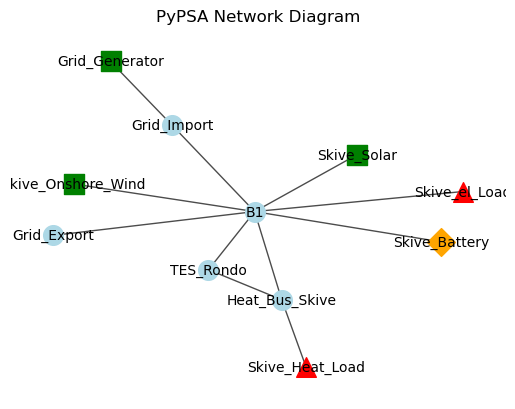

In [44]:
import networkx as nx
import matplotlib.pyplot as plt

# Start with buses and links
G = nx.Graph()

# Add buses
for bus_name in n.buses.index:
    G.add_node(bus_name, type="bus")

# Add links
for link_name, link in n.links.iterrows():
    G.add_edge(link.bus0, link.bus1, type="link", name=link_name)

# Add generators
for gen_name, gen in n.generators.iterrows():
    G.add_node(gen_name, type="generator")
    G.add_edge(gen.bus, gen_name, type="generator_connection")

# Add storage units
for su_name, su in n.storage_units.iterrows():
    G.add_node(su_name, type="storage")
    G.add_edge(su.bus, su_name, type="storage_connection")

# Add loads
for load_name, load in n.loads.iterrows():
    G.add_node(load_name, type="load")
    G.add_edge(load.bus, load_name, type="load_connection")

# Define positions (spring layout or use bus coordinates if available)
pos = nx.spring_layout(G, seed=10)
# Draw edges first
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

# Draw nodes by type with different shapes
node_shapes = {
    "bus": ("o", "lightblue"),          # circle
    "generator": ("s", "green"),        # square
    "storage": ("D", "orange"),         # diamond
    "load": ("^", "red")                # triangle
}

for ntype, (shape, color) in node_shapes.items():
    nodes_of_type = [node for node, attr in G.nodes(data=True) if attr["type"] == ntype]
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes_of_type,
                           node_color=color,
                           node_shape=shape,
                           node_size=200,
                           label=ntype.capitalize())

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Add legend
#plt.legend(scatterpoints=1)
plt.axis("off")
plt.title("PyPSA Network Diagram")
plt.show()

In [45]:
#conda install graphviz

In [46]:
import graphviz

In [246]:
# Draw the network
pypsatopo.generate(n)

[ERR] The tool 'dot' is not installed or could not be found (please visit https://graphviz.org/download to download and install it)!


-1

<Axes: xlabel='snapshot'>

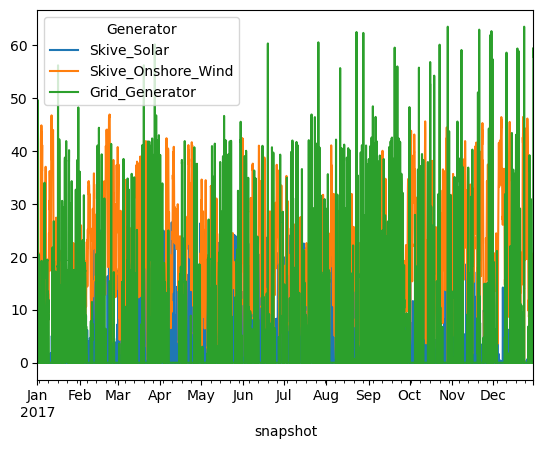

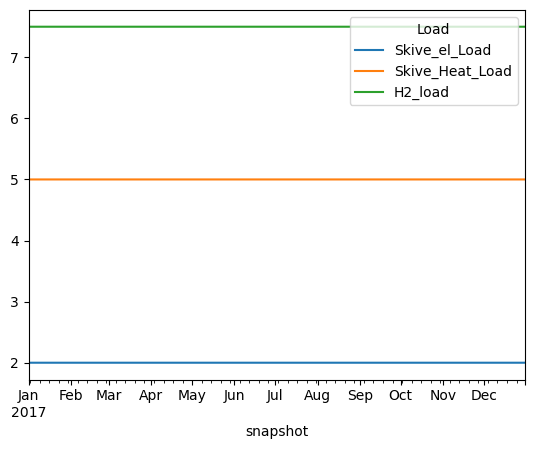

In [142]:
n.generators_t.p.plot()
n.loads_t.p.plot()

In [48]:
# Safe access with fallback
if "Skive_Battery" in n.storage_units_t.p_dispatch.columns:
    n.storage_units_t.p_dispatch["Skive_Battery"].head()
else:
    print("ERROR: 'Skive_Battery' results not found after optimization")
    print("Available storage units:", n.storage_units_t.p_dispatch.columns.tolist())

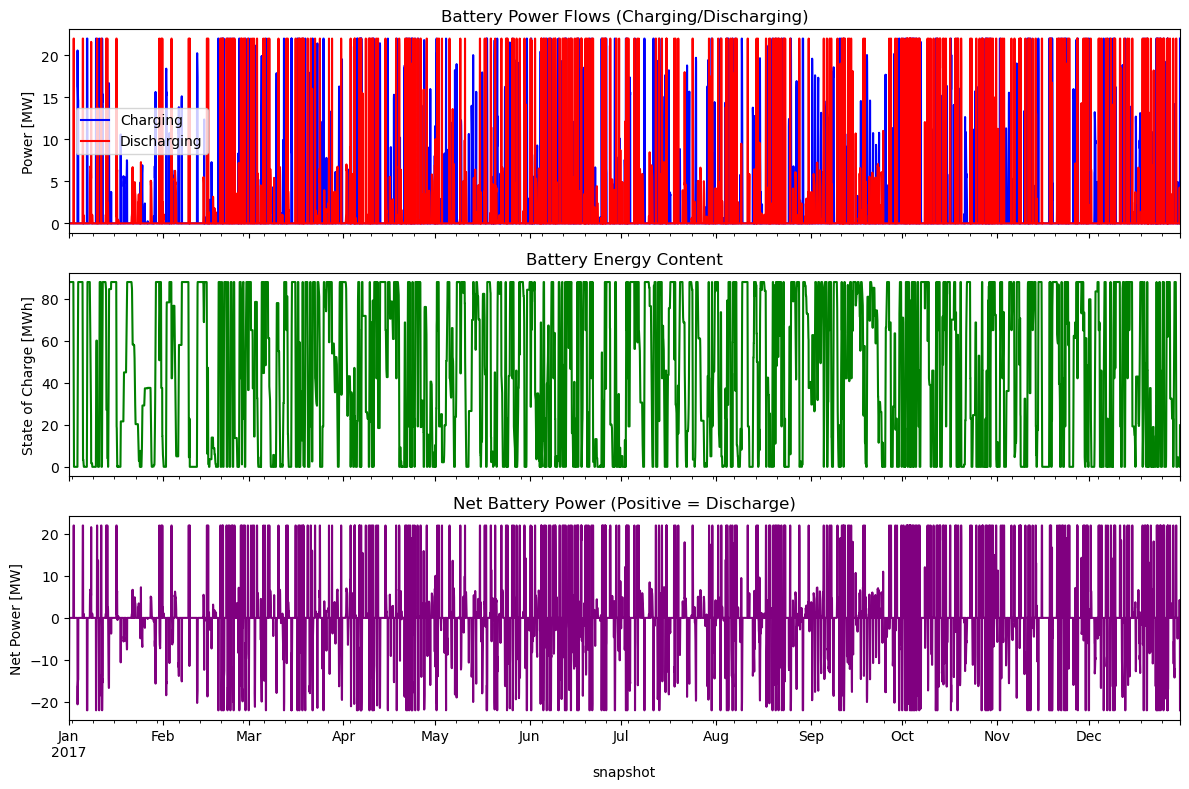

In [49]:
# Discharge power (positive when delivering electricity)
n.storage_units_t.p_dispatch["Skive_Battery"].head()

# Charging power (positive when charging)
n.storage_units_t.p_store["Skive_Battery"].head()

n.storage_units_t.state_of_charge["Skive_Battery"].head()


fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

n.storage_units_t.p_store["Skive_Battery"].plot(ax=ax[0], label="Charging", color="blue")
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax[0], label="Discharging", color="red")
ax[0].set_ylabel("Power [MW]")
ax[0].legend()
ax[0].set_title("Battery Power Flows (Charging/Discharging)")

n.storage_units_t.state_of_charge["Skive_Battery"].plot(ax=ax[1], color="green")
ax[1].set_ylabel("State of Charge [MWh]")
ax[1].set_title("Battery Energy Content")

# Optional: plot net power (discharge - charge)
net_p = n.storage_units_t.p_dispatch["Skive_Battery"] - n.storage_units_t.p_store["Skive_Battery"]
net_p.plot(ax=ax[2], color="purple")
ax[2].set_ylabel("Net Power [MW]")
ax[2].set_title("Net Battery Power (Positive = Discharge)")

plt.tight_layout()
plt.show()


<Axes: xlabel='snapshot'>

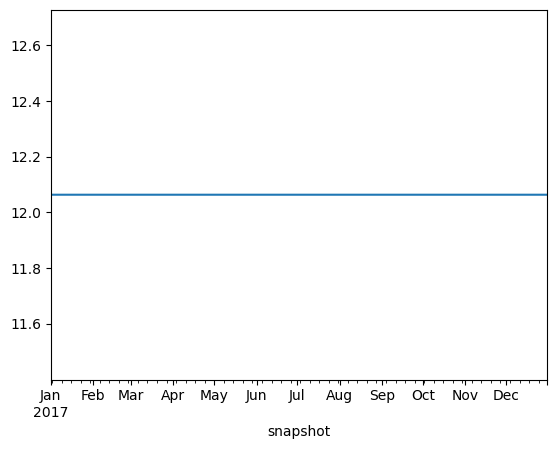

In [143]:
n.links_t.p0["Electrolyzer"].reindex(n.snapshots).plot()

<Axes: xlabel='snapshot'>

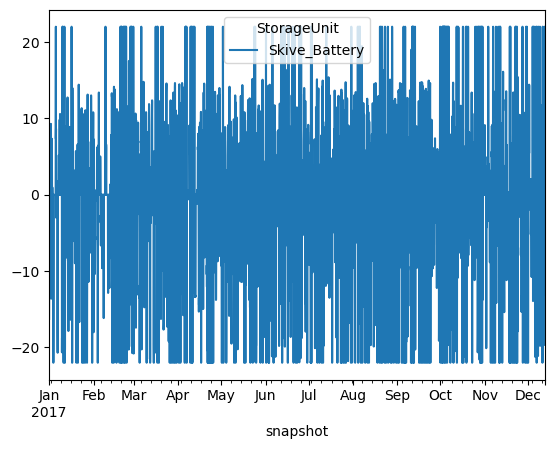

In [78]:
n.storage_units_t.p.loc["2017-01-01":"2017-12-12"].plot()

<Axes: xlabel='snapshot'>

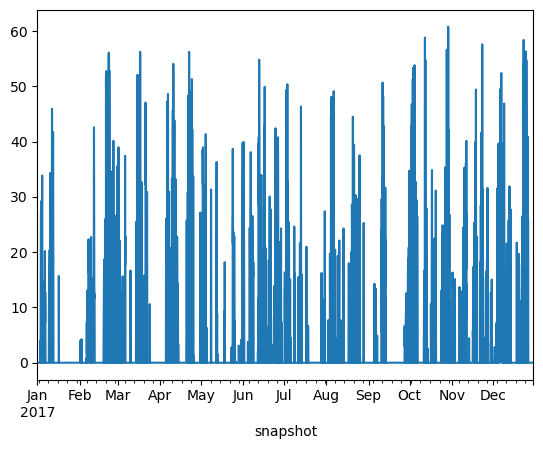

In [77]:

# align to network snapshots (fill missing with 0)
n.links_t.p0["Exports"].reindex(n.snapshots).plot()

<Axes: xlabel='snapshot'>

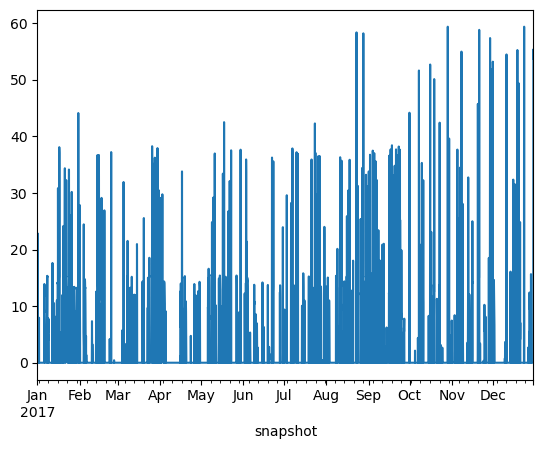

In [79]:
n.links_t.p0["Imports"].reindex(n.snapshots).plot()


<Axes: xlabel='snapshot'>

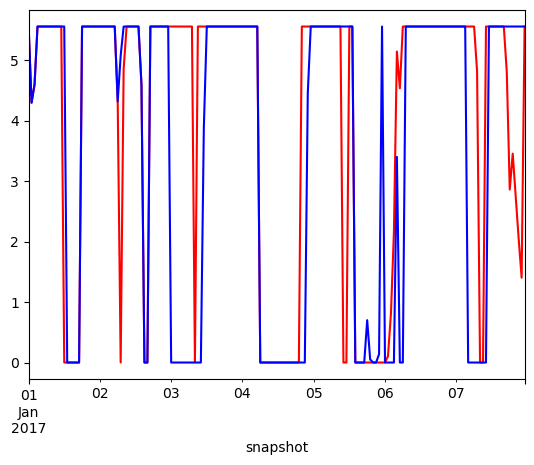

In [53]:
n.links_t.p0["Boiler_Skive"][0:24*7*1].plot(color = "red")
n_rh24_0.links_t.p0["Boiler_Skive"][0:24*7*1].plot(color = "blue")

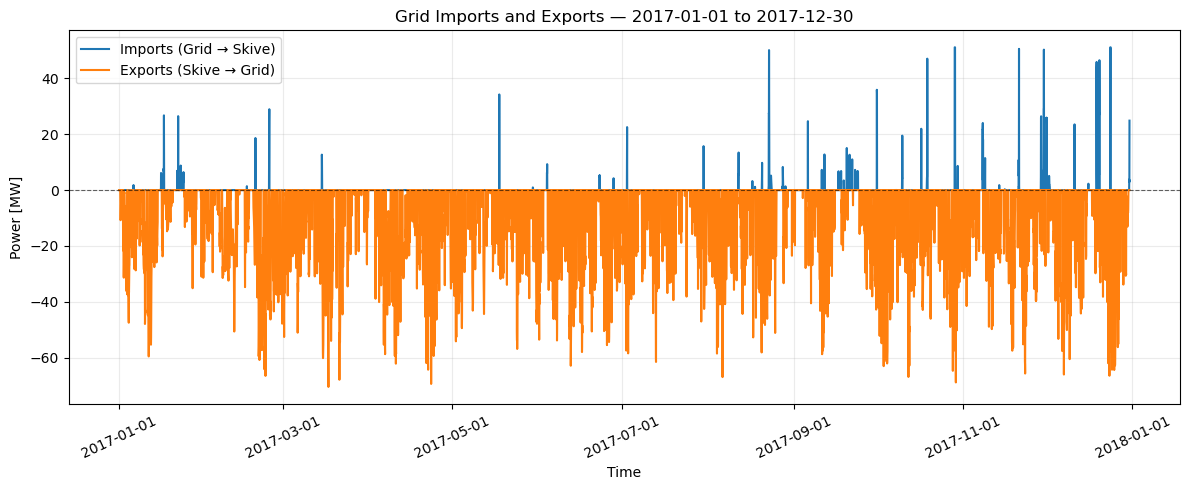

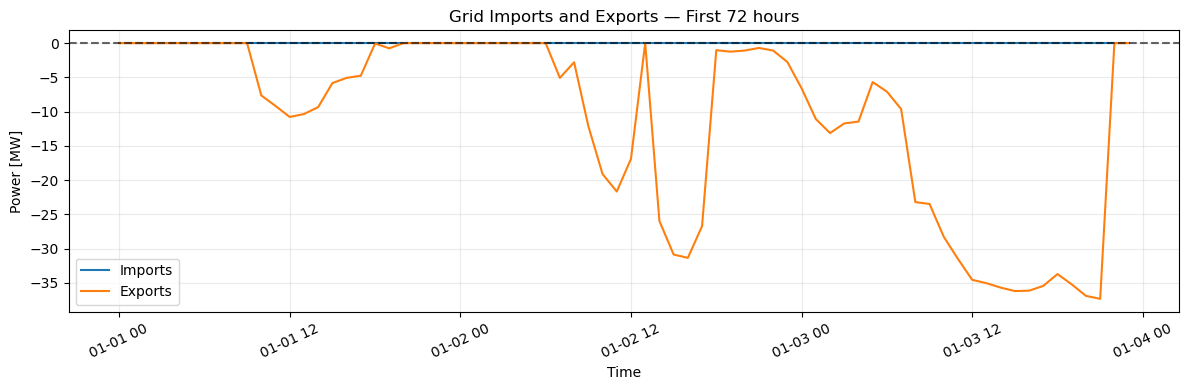

In [54]:
# ...existing code...
import matplotlib.dates as mdates

# align to network snapshots (fill missing with 0)
imports = n.links_t.p0["Imports"].reindex(n.snapshots)
exports = -n.links_t.p0["Exports"].reindex(n.snapshots)

# choose timeframe
start_date = "2017-01-01"
end_date   = "2017-12-30"

# full week plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(imports.loc[start_date:end_date].index, imports.loc[start_date:end_date].values,
        label="Imports (Grid → Skive)", color="#1f77b4", linewidth=1.5)
ax.plot(exports.loc[start_date:end_date].index, exports.loc[start_date:end_date].values,
        label="Exports (Skive → Grid)", color="#ff7f0e", linewidth=1.5)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Grid Imports and Exports — {start_date} to {end_date}")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# zoom: first 72 hours
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(imports.iloc[0:24*3].index, imports.iloc[0:24*3].values, label="Imports", color="#1f77b4")
ax.plot(exports.iloc[0:24*3].index, exports.iloc[0:24*3].values, label="Exports", color="#ff7f0e")
ax.axhline(0, color="k", linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title("Grid Imports and Exports — First 72 hours")
ax.legend()
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<Axes: xlabel='snapshot'>

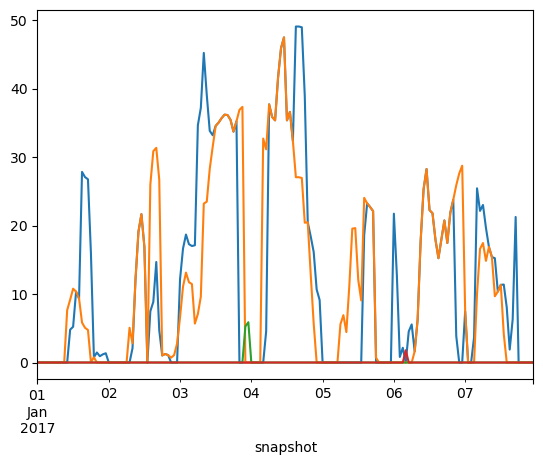

In [56]:
n_rh24_0.links_t.p0["Exports"][0:24*7*1].plot()
n.links_t.p0["Exports"][0:24*7*1].plot()

n_rh24_0.links_t.p0["Imports"][0:24*7*1].plot()
n.links_t.p0["Imports"][0:24*7*1].plot()


In [86]:
n.links_t.p0

Link,Boiler_Skive,El_to_TES_Rondo,TES_Rondo_to_Heat_Bus_Skive,Imports,Exports
snapshot,,,,,
2017-01-01 00:00:00,5.555556,2.304444,0.000000,0.000000,0.0
2017-01-01 01:00:00,4.296000,0.000000,1.259556,0.000000,0.0
2017-01-01 02:00:00,4.595516,0.000000,0.960039,0.000000,0.0
2017-01-01 03:00:00,5.555556,0.000000,0.000000,0.000000,0.0
2017-01-01 04:00:00,5.555556,6.995595,0.000000,0.000000,0.0
...,...,...,...,...,...
2017-12-30 18:00:00,2.050000,0.000000,3.505556,0.000000,0.0
2017-12-30 19:00:00,5.555556,0.000000,0.000000,0.000000,0.0
2017-12-30 20:00:00,5.555556,0.000000,0.000000,3.780985,0.0


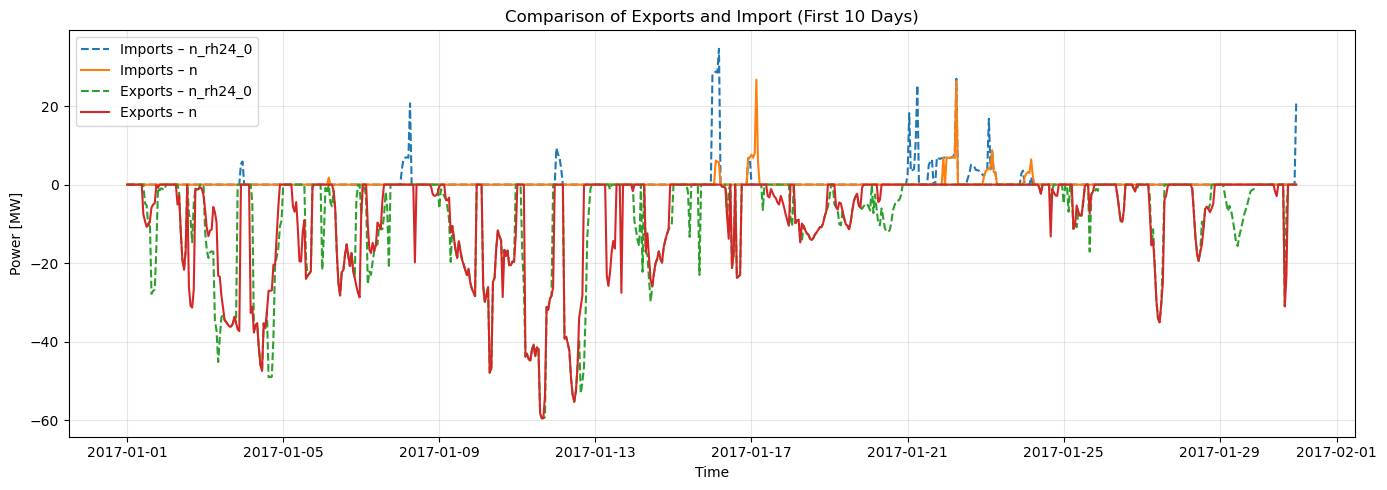

In [57]:
import matplotlib.pyplot as plt

n_days = 30

# --- Exports comparison ---
plt.figure(figsize=(14,5))
plt.plot(n_rh24_0.links_t.p0["Imports"][0:24*n_days], label="Imports – n_rh24_0", linestyle = "--")
plt.plot(n.links_t.p0["Imports"][0:24*n_days], label="Imports – n")
plt.plot(-n_rh24_0.links_t.p0["Exports"][0:24*n_days], label="Exports – n_rh24_0", linestyle = "--")
plt.plot(-n.links_t.p0["Exports"][0:24*n_days], label="Exports – n")
plt.title("Comparison of Exports and Import (First 10 Days)")
plt.xlabel("Time")
plt.ylabel("Power [MW]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
import pandas as pd

# Full time series
imp_n = n.links_t.p0["Imports"]
exp_n = n.links_t.p0["Exports"]

imp_rh = n_rh24_0.links_t.p0["Imports"]
exp_rh = n_rh24_0.links_t.p0["Exports"]

# ---- COUNT number of hours importing/exporting ----
results = {
    "Network": ["n", "n_rh24_0"],
    "Import hours": [(imp_n > 0).sum(), (imp_rh > 0).sum()],
    "Export hours": [(exp_n > 0).sum(), (exp_rh > 0).sum()],

    # ---- TOTAL energy imported/exported (MWh) ----
    "Total import (MWh)": [imp_n.sum(), imp_rh.sum()],
    "Total export (MWh)": [exp_n.sum(), exp_rh.sum()],
}

df_results = pd.DataFrame(results)
print(df_results)


    Network  Import hours  Export hours  Total import (MWh)  \
0         n           229          4152         2562.701976   
1  n_rh24_0           394          4007         5070.230207   

   Total export (MWh)  
0        87345.460952  
1        90044.985776  


In [59]:
df_results

,Network,Import hours,Export hours,Total import (MWh),Total export (MWh)
0,n,229,4152,2562.701976,87345.460952
1,n_rh24_0,394,4007,5070.230207,90044.985776


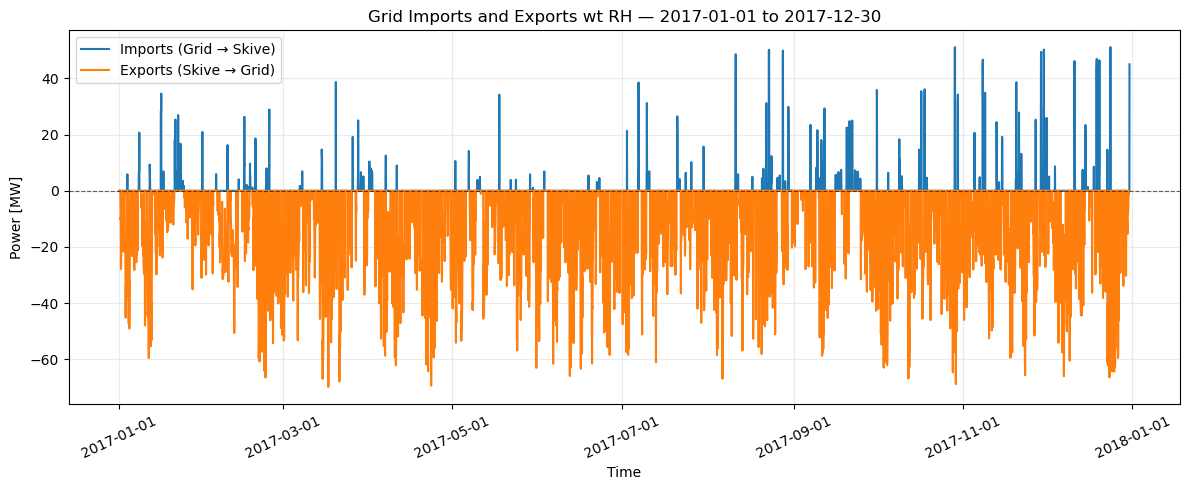

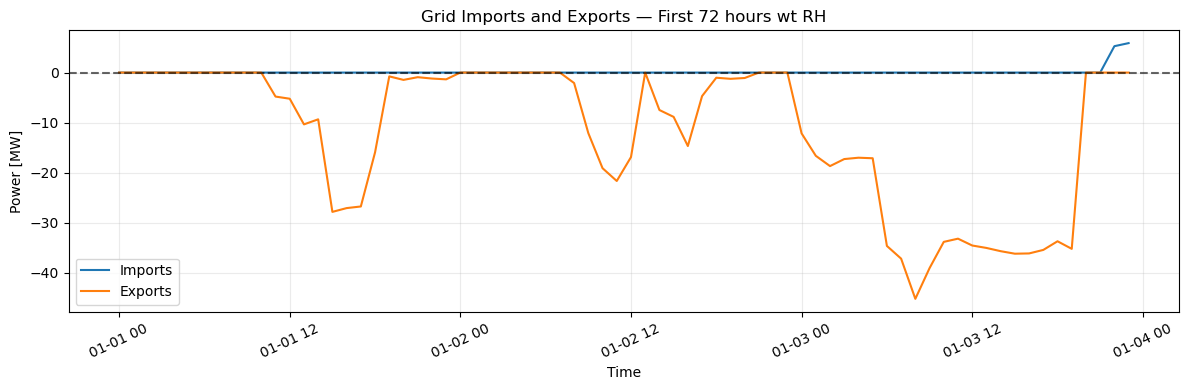

In [60]:
# ...existing code...
import matplotlib.dates as mdates

# align to network snapshots (fill missing with 0)
imports = n_rh24_0.links_t.p0["Imports"].reindex(n.snapshots)
exports = -n_rh24_0.links_t.p0["Exports"].reindex(n.snapshots)

# choose timeframe
start_date = "2017-01-01"
end_date   = "2017-12-30"

# full week plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(imports.loc[start_date:end_date].index, imports.loc[start_date:end_date].values,
        label="Imports (Grid → Skive)", color="#1f77b4", linewidth=1.5)
ax.plot(exports.loc[start_date:end_date].index, exports.loc[start_date:end_date].values,
        label="Exports (Skive → Grid)", color="#ff7f0e", linewidth=1.5)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Grid Imports and Exports wt RH — {start_date} to {end_date}")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# zoom: first 72 hours
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(imports.iloc[0:24*3].index, imports.iloc[0:24*3].values, label="Imports", color="#1f77b4")
ax.plot(exports.iloc[0:24*3].index, exports.iloc[0:24*3].values, label="Exports", color="#ff7f0e")
ax.axhline(0, color="k", linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title("Grid Imports and Exports — First 72 hours wt RH")
ax.legend()
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

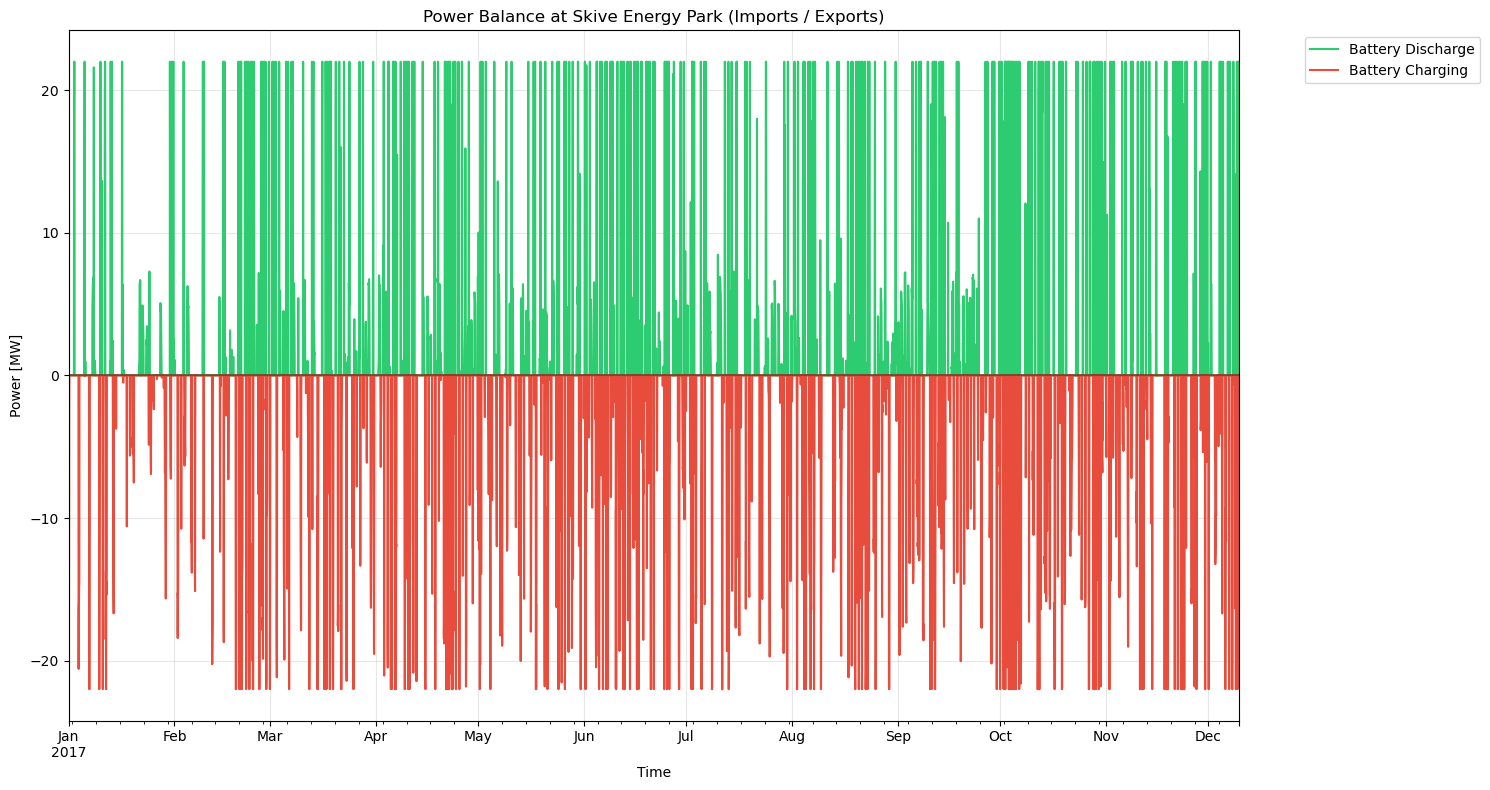

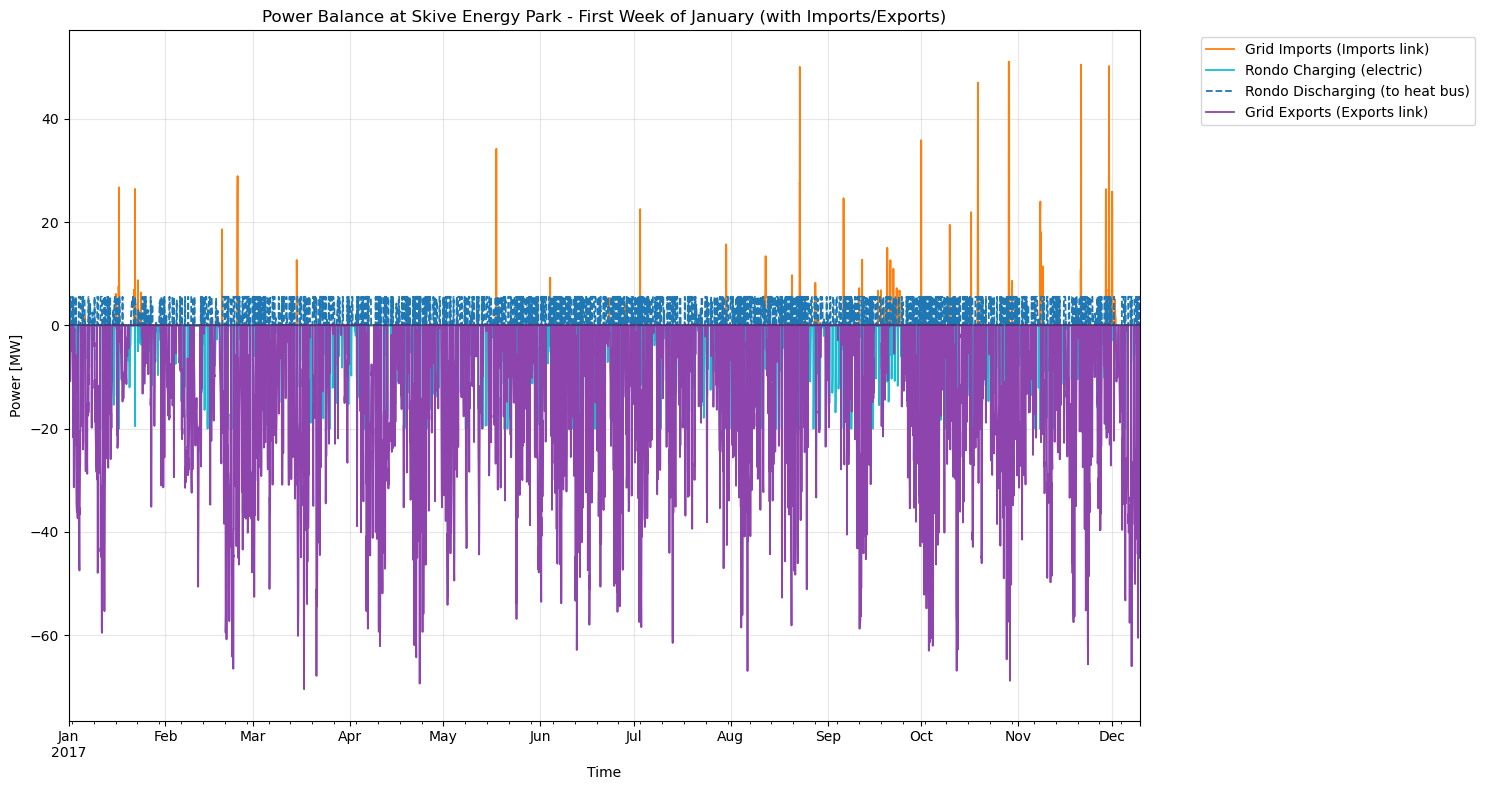

In [61]:
# ...existing code...
import matplotlib.dates as mdates

def safe_series(df, key):
    try:
        return df[key].reindex(n.snapshots).fillna(0)
    except Exception:
        return pd.Series(0.0, index=n.snapshots, name=key)

# read Imports/Exports (fall back to zero series if missing)
imports = safe_series(n.links_t.p0, "Imports")
exports = safe_series(n.links_t.p0, "Exports")

exports = -exports  # invert sign for exports to match convention

# positive import = grid -> B1, positive export = B1 -> grid
#imports_pos = imports.clip(lower=0)
#exports_pos = exports.clip(lower=0

start_date = '2017-01-01'
end_date = '2017-12-10'

# colors
col_grid_imp = '#FF7F0E'
col_grid_exp = '#8E44AD'

# Main plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# battery and rondo flows (existing)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax, label="Battery Discharge", color='#2ECC71', linewidth=1.5)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(ax=ax, label="Battery Charging", color='#E74C3C', linewidth=1.5)

#(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots))).plot(ax=ax, label="Rondo Charging (electric)", color='#17BECF', linewidth=1.25)
#n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).plot(ax=ax, label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.25)

# plot Imports/Exports
#imports.plot(ax=ax, label="Imports (Imports link)", color=col_grid_imp, linewidth=1.3, alpha=0.9)
#exports.plot(ax=ax, label="Exports (Exports link)", color=col_grid_exp, linewidth=1.3, alpha=0.9)

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (Imports / Exports)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(start_date, end_date)
plt.show()

# Week view
plt.figure(figsize=(15, 8))

#n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(label="Solar PV", color='#FFC300', linewidth=1.3)
#n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(label="Wind", color='#0057E7', linewidth=1.3)
#n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(label="Battery Discharge", color='#2ECC71', linewidth=1.3)
imports.loc[start_date:end_date].plot(label="Grid Imports (Imports link)", color=col_grid_imp, linewidth=1.3)
#(-n.links_t.p0.get("Boiler_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Electric Boiler", color='#7F8C8D', linewidth=1.3)
(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Rondo Charging (electric)", color='#17BECF', linewidth=1.3)
n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date].plot(label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.3)
#(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(label="Battery Charging", color='#E74C3C', linewidth=1.3)
exports.loc[start_date:end_date].plot(label="Grid Exports (Exports link)", color=col_grid_exp, linewidth=1.3)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January (with Imports/Exports)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(start_date, end_date)
plt.tight_layout()
plt.show()

In [62]:
"Optimal Generator Capacity (GW)";
n.generators.p_nom_opt # in GW

Generator
Skive_Solar           36.000000
Skive_Onshore_Wind    54.000000
Grid_Generator        51.088202
Name: p_nom_opt, dtype: float64

In [63]:
"Minimum cost of the system";
n.objective/1e9 # Bn of EUR annum

-0.0024125370356610286

In [64]:
n.stores.e_nom_opt

Store
Rondo_Concrete_Heat_Storage      100.000000
Grid_Store                     84725.097124
Name: e_nom_opt, dtype: float64

In [65]:
n.loads_t

{'p_set': Empty DataFrame
 Columns: []
 Index: [2017-01-01 00:00:00, 2017-01-01 01:00:00, 2017-01-01 02:00:00, 2017-01-01 03:00:00, 2017-01-01 04:00:00, 2017-01-01 05:00:00, 2017-01-01 06:00:00, 2017-01-01 07:00:00, 2017-01-01 08:00:00, 2017-01-01 09:00:00, 2017-01-01 10:00:00, 2017-01-01 11:00:00, 2017-01-01 12:00:00, 2017-01-01 13:00:00, 2017-01-01 14:00:00, 2017-01-01 15:00:00, 2017-01-01 16:00:00, 2017-01-01 17:00:00, 2017-01-01 18:00:00, 2017-01-01 19:00:00, 2017-01-01 20:00:00, 2017-01-01 21:00:00, 2017-01-01 22:00:00, 2017-01-01 23:00:00, 2017-01-02 00:00:00, 2017-01-02 01:00:00, 2017-01-02 02:00:00, 2017-01-02 03:00:00, 2017-01-02 04:00:00, 2017-01-02 05:00:00, 2017-01-02 06:00:00, 2017-01-02 07:00:00, 2017-01-02 08:00:00, 2017-01-02 09:00:00, 2017-01-02 10:00:00, 2017-01-02 11:00:00, 2017-01-02 12:00:00, 2017-01-02 13:00:00, 2017-01-02 14:00:00, 2017-01-02 15:00:00, 2017-01-02 16:00:00, 2017-01-02 17:00:00, 2017-01-02 18:00:00, 2017-01-02 19:00:00, 2017-01-02 20:00:00, 2017-01

Load names: ['Skive_el_Load', 'Skive_Heat_Load']

Static loads table:


,bus,carrier,type,p_set,q_set,sign,active,p_nom_extendable
Load,,,,,,,,
Skive_el_Load,B1,,,2.0,0.0,-1.0,True,NaN
Skive_Heat_Load,Heat_Bus_Skive,heat,,5.0,0.0,-1.0,True,False



Loads time-series columns: ['Skive_el_Load', 'Skive_Heat_Load']


Load,Skive_el_Load,Skive_Heat_Load
snapshot,,
2017-01-01 00:00:00,2.0,5.0
2017-01-01 01:00:00,2.0,5.0
2017-01-01 02:00:00,2.0,5.0
2017-01-01 03:00:00,2.0,5.0
2017-01-01 04:00:00,2.0,5.0


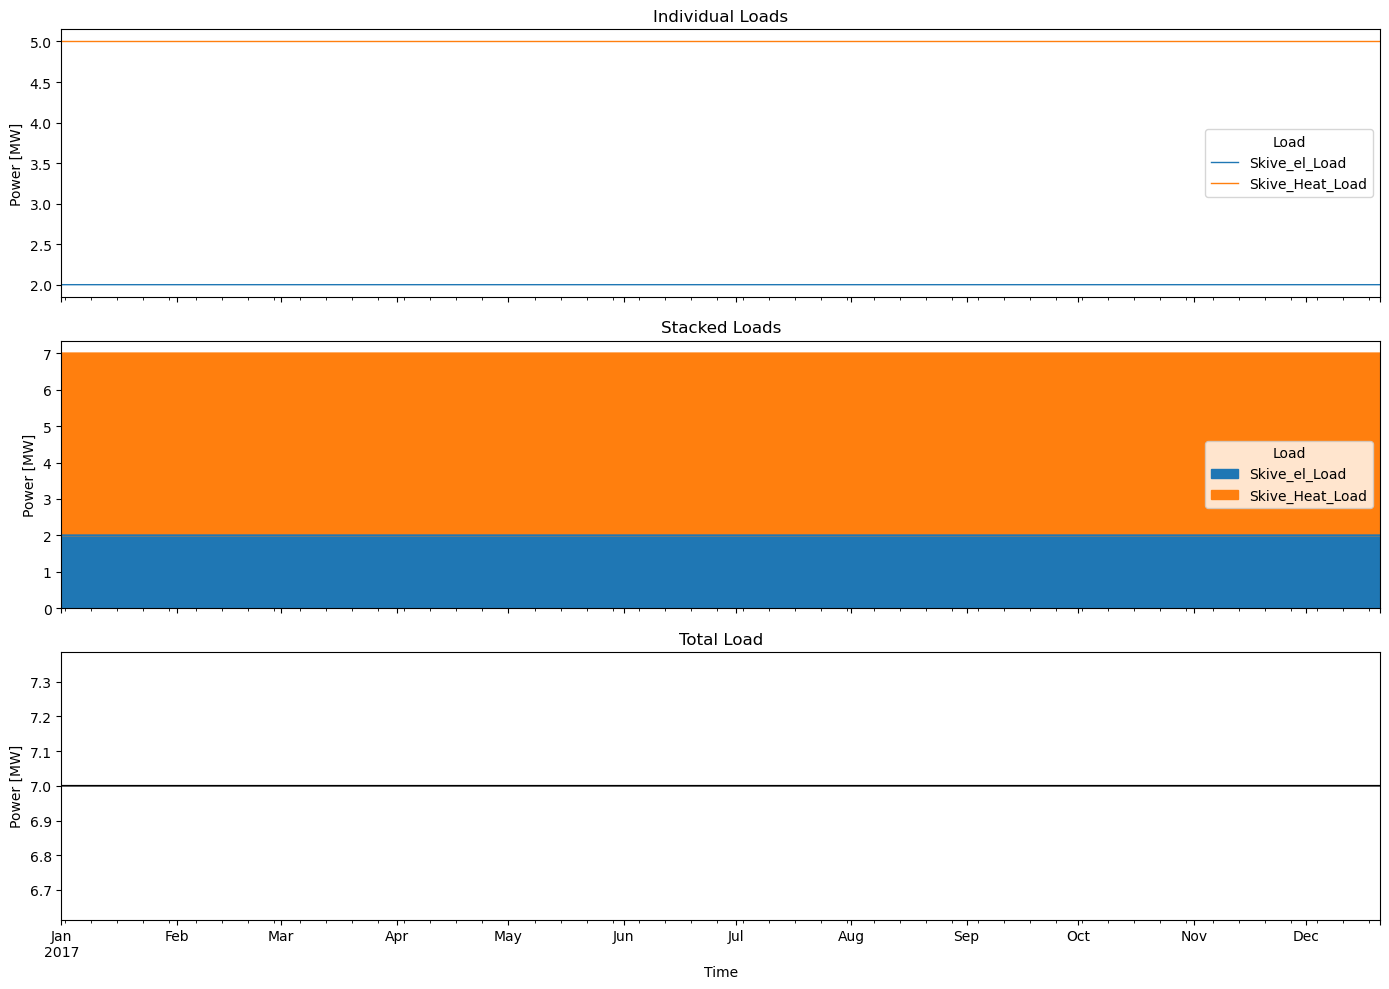

In [66]:
# ...existing code...
# Show loads and time-series
print("Load names:", n.loads.index.tolist())
print("\nStatic loads table:")
display(n.loads)

print("\nLoads time-series columns:", n.loads_t.p.columns.tolist())
display(n.loads_t.p.head())

# Plot individual loads, stacked loads and total load for a short period
import matplotlib.pyplot as plt
start = "2017-01-01"
end   = "2017-12-20"

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1) Individual loads
n.loads_t.p.loc[start:end].plot(ax=axs[0], linewidth=1)
axs[0].set_title("Individual Loads")
axs[0].set_ylabel("Power [MW]")

# 2) Stacked area of loads
n.loads_t.p.loc[start:end].plot.area(ax=axs[1])
axs[1].set_title("Stacked Loads")
axs[1].set_ylabel("Power [MW]")

# 3) Total system load
total_load = n.loads_t.p.sum(axis=1)
total_load.loc[start:end].plot(ax=axs[2], color="k", linewidth=1.25)
axs[2].set_title("Total Load")
axs[2].set_ylabel("Power [MW]")
axs[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [ ]:
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].max(), n.links_t.p0["Heat_Exchanger_Rondo"].max()

(6.944444444444445, 6.25)

In [283]:
6.25/6.94

0.9005763688760806

<Axes: xlabel='snapshot'>

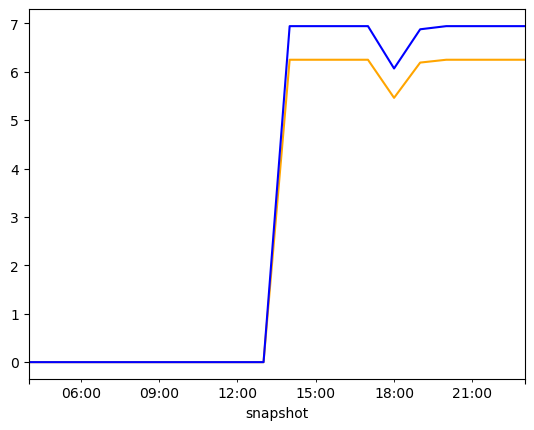

In [305]:

n.links_t.p0["Heat_Exchanger_Rondo"].reindex(n.snapshots)[100:120].plot(color = "orange")
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].reindex(n.snapshots)[100:120].plot(color = "blue")

<Axes: xlabel='snapshot'>

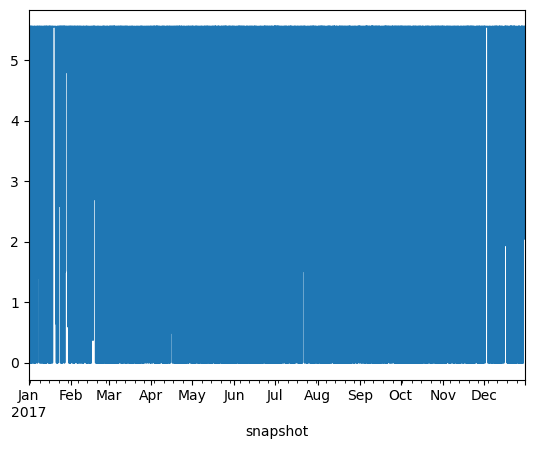

In [67]:
n.links_t.p0["Boiler_Skive"].reindex(n.snapshots).plot()

In [68]:
n.stores_t.p

Store,Rondo_Concrete_Heat_Storage,Grid_Store
snapshot,,
2017-01-01 00:00:00,-2.258356,0.0
2017-01-01 01:00:00,1.259556,0.0
2017-01-01 02:00:00,0.960039,0.0
2017-01-01 03:00:00,0.000000,0.0
2017-01-01 04:00:00,-6.855683,0.0
...,...,...
2017-12-30 18:00:00,3.505556,0.0
2017-12-30 19:00:00,0.000000,0.0
2017-12-30 20:00:00,0.000000,0.0


<Axes: xlabel='snapshot'>

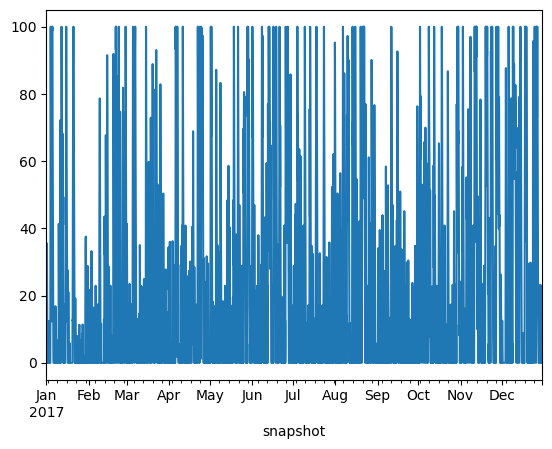

In [69]:
"Rondo Heat Energy Storage";
n.stores_t.e['Rondo_Concrete_Heat_Storage'].plot()

<Axes: xlabel='snapshot'>

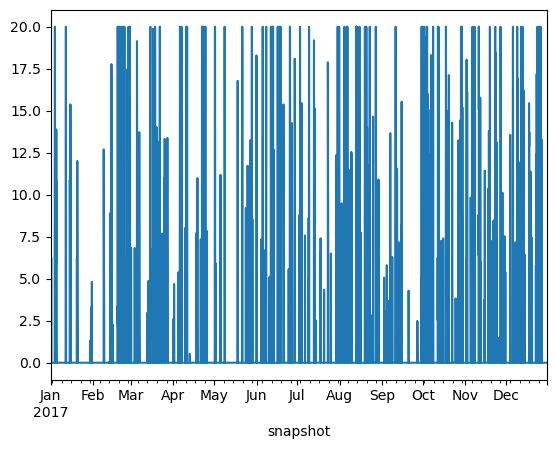

(412008.0, 412056.0)

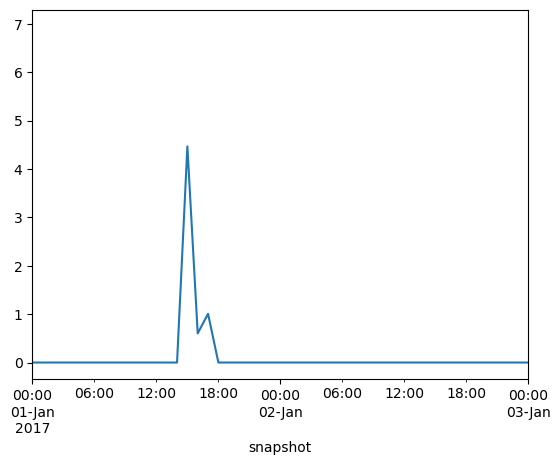

In [249]:
display(n.links_t.p0["El_to_TES_Rondo"].plot())
plt.show()
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot()
plt.xlim('2017-01-01 00:00Z', '2017-01-03 00:00Z')

<Axes: >

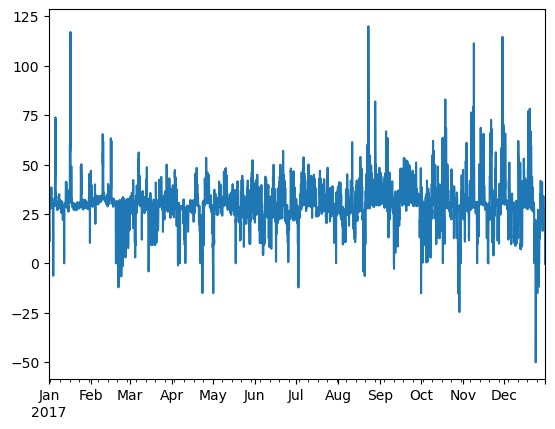

In [71]:
DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).plot()

<Axes: xlabel='snapshot'>

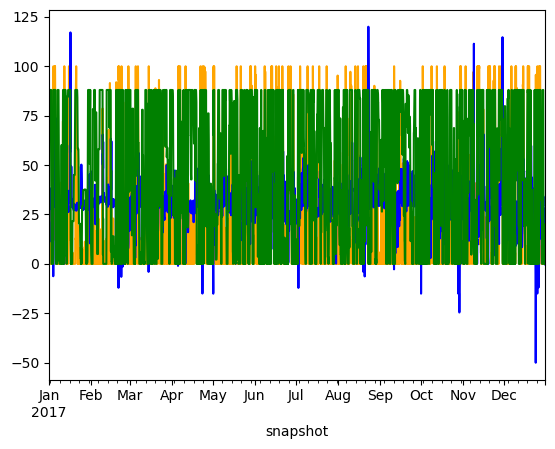

In [72]:
"Plot the Battery SOC + TES and el_Prices";


n.stores_t.e['Rondo_Concrete_Heat_Storage'].plot(color = "orange")
DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).plot(color = "blue")
n.storage_units_t.state_of_charge["Skive_Battery"].plot(color="green")

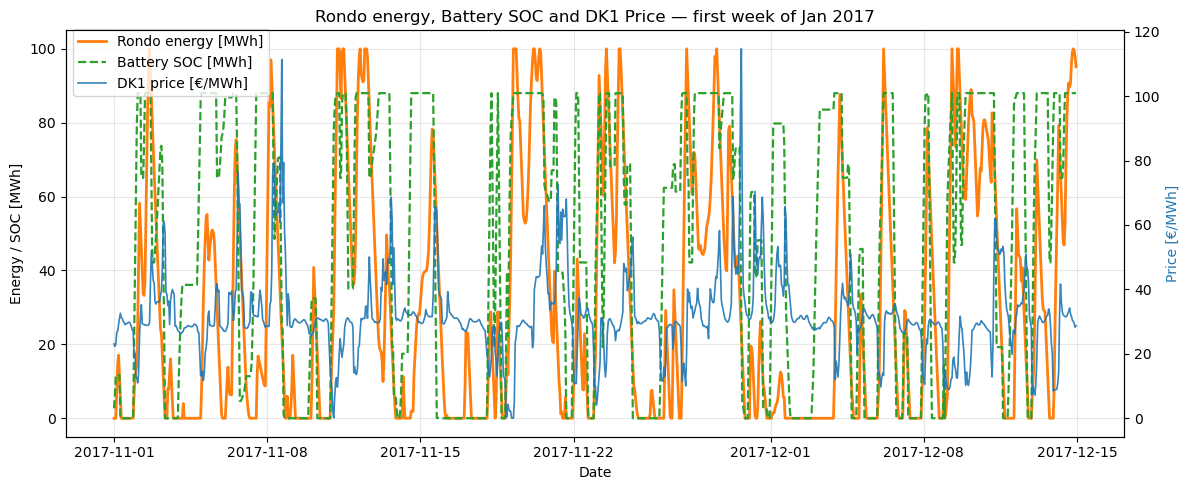

In [73]:
# ...existing code...
import matplotlib.dates as mdates

# Shorter timeframe
start = "2017-11-01"
end   = "2017-12-14"

# Safe aligned series
price = DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).reindex(n.snapshots).fillna(method="ffill").loc[start:end]
rondo = n.stores_t.e.get("Rondo_Concrete_Heat_Storage", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).fillna(0).loc[start:end]
battery_soc = n.storage_units_t.state_of_charge.get("Skive_Battery", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).fillna(0).loc[start:end]

# Plot
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()

ax1.plot(rondo.index, rondo.values, color="tab:orange", lw=2, label="Rondo energy [MWh]")
ax1.plot(battery_soc.index, battery_soc.values, color="tab:green", lw=1.6, linestyle="--", label="Battery SOC [MWh]")

ax2.plot(price.index, price.values, color="tab:blue", lw=1.2, alpha=0.9, label="DK1 price [€/MWh]")

# Styling
ax1.set_ylabel("Energy / SOC [MWh]", color="k")
ax2.set_ylabel("Price [€/MWh]", color="tab:blue")
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
ax1.grid(alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", bbox_to_anchor=(0,1.02))

plt.title("Rondo energy, Battery SOC and DK1 Price — first week of Jan 2017")
plt.tight_layout()
plt.show()
# ...existing code...

In [74]:
n.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

snapshot
2017-11-01 00:00:00    2.164444
2017-11-01 01:00:00    4.324444
2017-11-01 02:00:00    5.728444
2017-11-01 03:00:00    0.000000
2017-11-01 04:00:00    0.000000
                         ...   
2017-12-14 19:00:00    0.000000
2017-12-14 20:00:00    0.000000
2017-12-14 21:00:00    0.000000
2017-12-14 22:00:00    0.000000
2017-12-14 23:00:00    0.000000
Name: Skive_Battery, Length: 1056, dtype: float64

In [75]:
n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

snapshot
2017-11-01 00:00:00    0.000000
2017-11-01 01:00:00    0.000000
2017-11-01 02:00:00    0.000000
2017-11-01 03:00:00    6.970444
2017-11-01 04:00:00    7.834444
                         ...   
2017-12-14 19:00:00    4.378444
2017-12-14 20:00:00    2.164444
2017-12-14 21:00:00    0.760444
2017-12-14 22:00:00    0.000000
2017-12-14 23:00:00    0.000000
Name: El_to_TES_Rondo, Length: 1056, dtype: float64

Correlation matrix:
                      price_eur_mwh  rondo_e_mwh  battery_soc_mwh  solar_mw  \
price_eur_mwh              1.000000    -0.058513        -0.043295  0.080298   
rondo_e_mwh               -0.058513     1.000000         0.549070  0.038499   
battery_soc_mwh           -0.043295     0.549070         1.000000  0.041647   
solar_mw                   0.080298     0.038499         0.041647  1.000000   
wind_mw                   -0.422269     0.107939        -0.029268 -0.001075   
boiler_mw                 -0.308205    -0.272410        -0.110159  0.090001   
tes_charge_mw             -0.358574     0.345834         0.279330  0.215669   
tes_discharge_mw           0.308205     0.272410         0.110159 -0.090001   
battery_charge_mw         -0.393014    -0.023431         0.063633  0.144954   
battery_discharge_mw       0.291295     0.055946        -0.113139 -0.070270   

                       wind_mw  boiler_mw  tes_charge_mw  tes_discharge_mw  \
price_eur_mwh        -0.422269  

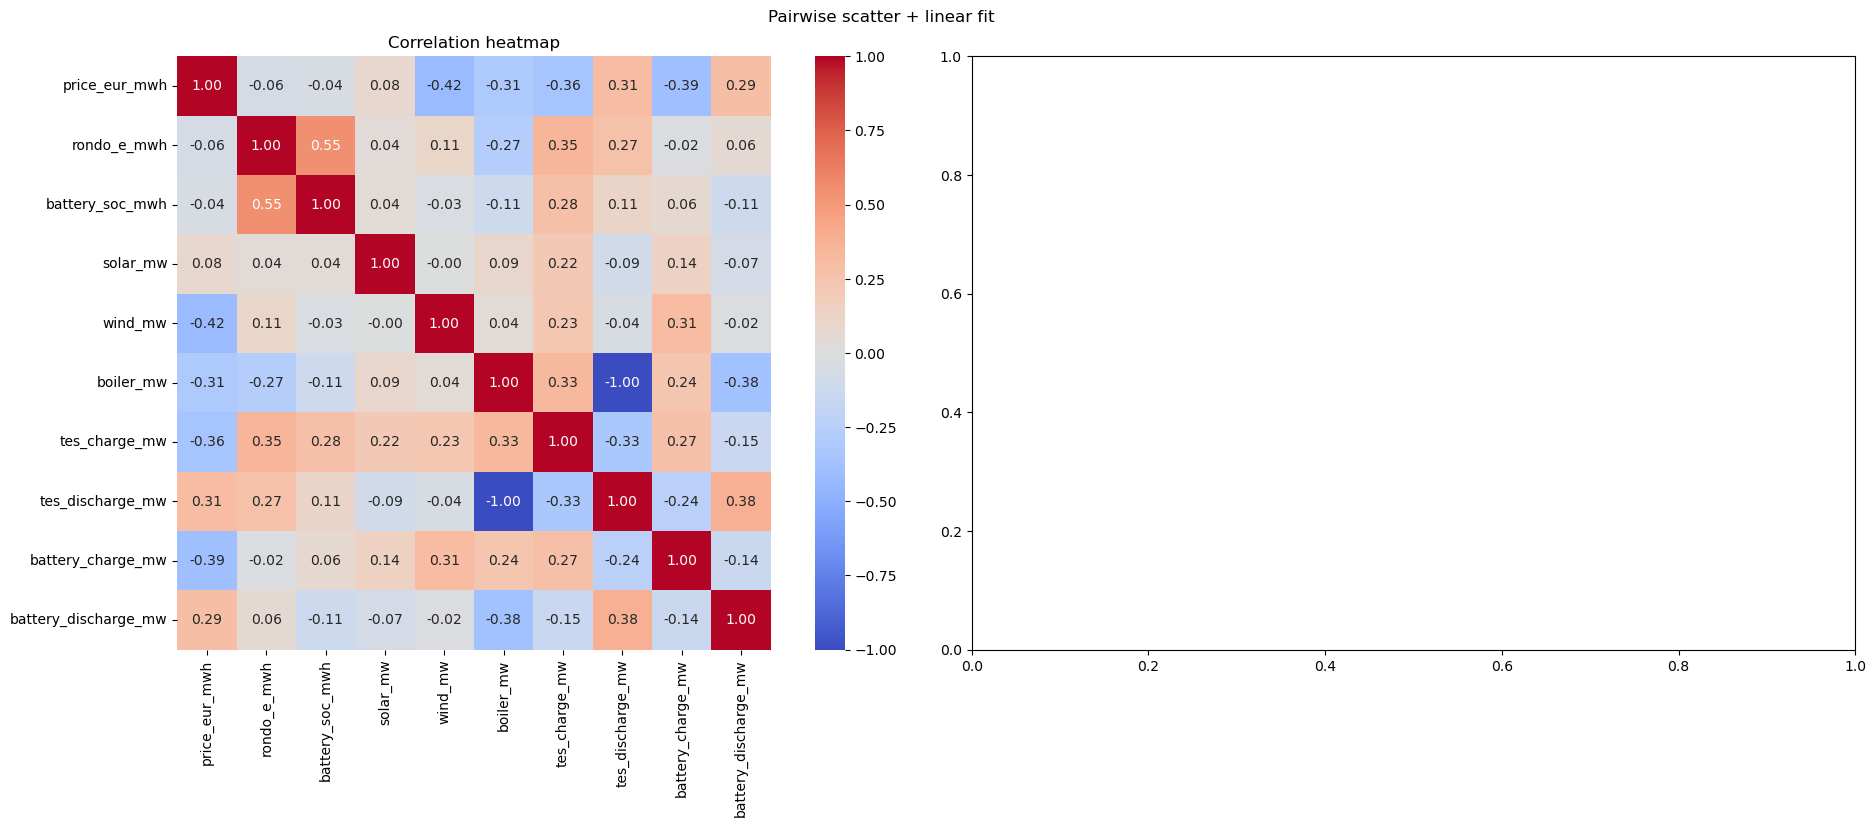

In [76]:
# ...existing code...
import seaborn as sns

# Shorter timeframe (reuse existing window or change as needed)
start = "2017-01-01"
end   = "2017-12-31"

# Safe aligned series
price = DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).reindex(n.snapshots).fillna(method="ffill").loc[start:end]
rondo = n.stores_t.e.get("Rondo_Concrete_Heat_Storage", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]
battery_soc = n.storage_units_t.state_of_charge.get("Skive_Battery", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

# add solar and wind generation
solar = n.generators_t.p.get("Skive_Solar", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]
wind  = n.generators_t.p.get("Skive_Onshore_Wind", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

# add boiler power
boiler = (n.links_t.p0.get("Boiler_Skive", pd.Series(0, index=n.snapshots))).reindex(n.snapshots).loc[start:end]

# add TES Rondo charging and discharging
tes_charge = (n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots))).reindex(n.snapshots).loc[start:end]
tes_discharge = n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

# add battery charge and discharge powers
battery_charge = (n.storage_units_t.p_store.get("Skive_Battery", pd.Series(0, index=n.snapshots))).reindex(n.snapshots).loc[start:end]
battery_discharge = n.storage_units_t.p_dispatch.get("Skive_Battery", pd.Series(0, index=n.snapshots)).reindex(n.snapshots).loc[start:end]

# Build dataframe and drop missing values
df = pd.concat([price, rondo, battery_soc, solar, wind, boiler, tes_charge, tes_discharge, battery_charge, battery_discharge], axis=1)
df.columns = ["price_eur_mwh", "rondo_e_mwh", "battery_soc_mwh", "solar_mw", "wind_mw", "boiler_mw", "tes_charge_mw", "tes_discharge_mw", "battery_charge_mw", "battery_discharge_mw"]
df = df.dropna()

# Print correlation matrix
print("Correlation matrix:")
print(df.corr())

# Plot: heatmap + pairwise scatter with regression
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax[0], square=True)
ax[0].set_title("Correlation heatmap")

# pairplot opens its own figure — show it separately
#sns.pairplot(df, kind="reg", plot_kws={"scatter_kws": {"s": 8, "alpha": 0.4}, "line_kws": {"color": "red"}})

plt.suptitle("Pairwise scatter + linear fit", y=0.995)
plt.tight_layout()
plt.show()
# ...existing code...

In [247]:
n.stores_t.e['Rondo_Concrete_Heat_Storage']

snapshot
2017-01-01 00:00:00    0.0
2017-01-01 01:00:00    0.0
2017-01-01 02:00:00    0.0
2017-01-01 03:00:00    0.0
2017-01-01 04:00:00    0.0
                      ... 
2017-12-30 18:00:00    0.0
2017-12-30 19:00:00    0.0
2017-12-30 20:00:00    0.0
2017-12-30 21:00:00    0.0
2017-12-30 22:00:00    0.0
Name: Rondo_Concrete_Heat_Storage, Length: 8735, dtype: float64

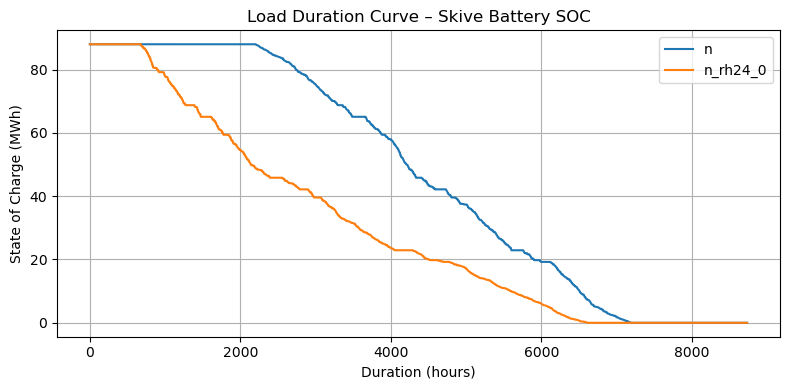

In [78]:


# Extract SOC time series for both networks
soc_n = n.storage_units_t.state_of_charge['Skive_Battery']
soc_rh = n_rh24_0.storage_units_t.state_of_charge['Skive_Battery']

# Sort both in descending order
soc_n_sorted = np.sort(soc_n)[::-1]
soc_rh_sorted = np.sort(soc_rh)[::-1]

plt.figure(figsize=(8,4))
plt.plot(soc_n_sorted, label='n')
plt.plot(soc_rh_sorted, label='n_rh24_0')

plt.title("Load Duration Curve – Skive Battery SOC")
plt.xlabel("Duration (hours)")
plt.ylabel("State of Charge (MWh)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



- in rolling horizion, the battery, is kept more empty and discharge more often
- A steeper gradient means the load changes rapidly over time. 
- In other words, there are short periods of very high or very low load, with fewer hours at intermediate values.

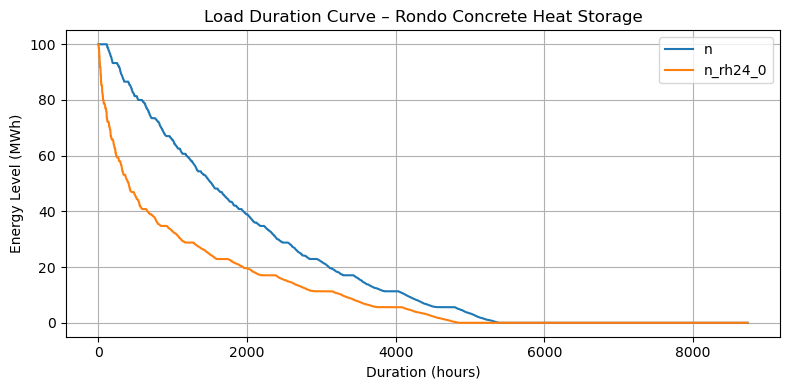

In [79]:


# Extract energy levels
e_n = n.stores_t.e['Rondo_Concrete_Heat_Storage']
e_rh = n_rh24_0.stores_t.e['Rondo_Concrete_Heat_Storage']

# Sort both in descending order
e_n_sorted = np.sort(e_n)[::-1]
e_rh_sorted = np.sort(e_rh)[::-1]

plt.figure(figsize=(8,4))
plt.plot(e_n_sorted, label='n')
plt.plot(e_rh_sorted, label='n_rh24_0')

plt.title("Load Duration Curve – Rondo Concrete Heat Storage")
plt.xlabel("Duration (hours)")
plt.ylabel("Energy Level (MWh)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Steep drop at the beginning:

Both curves start at the maximum energy (~100 MWh for blue, ~90 MWh for orange).

The steep slope at the start shows that high energy levels exist only for a short period — i.e., the storage is fully charged for relatively few hours.

Gradual slope afterward:

After the initial steep drop, the curves flatten, meaning lower energy levels persist for many more hours.

This corresponds to periods where the storage is partially charged and gradually discharges over longer durations.

Comparison between curves:

The orange curve (n_rh24_0) is consistently lower than the blue curve, meaning that in this scenario the storage doesn’t reach as high energy levels or starts discharging earlier.

Both curves hit zero energy after ~5500–6000 hours, indicating the storage is empty for the remaining hours of the year

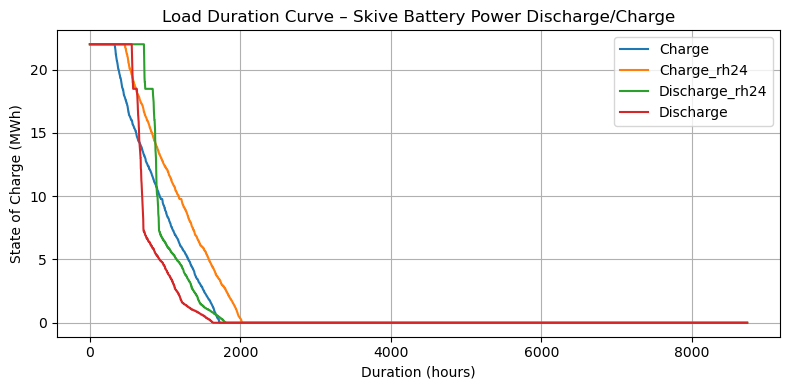

In [107]:
# Discharge power (positive when delivering electricity)
p_discharge_battery = n.storage_units_t.p_dispatch["Skive_Battery"]
p_rh24_discharge_battery = n_rh24_0.storage_units_t.p_dispatch["Skive_Battery"]

# Charging power (positive when charging)
p_charge_battery = n.storage_units_t.p_store["Skive_Battery"]
p_rh24_charge_battery = n_rh24_0.storage_units_t.p_store["Skive_Battery"]

# Sort both in descending order
p_discharge_battery_sorted = np.sort(p_discharge_battery)[::-1]
p_charge_battery_sorted = np.sort(p_charge_battery)[::-1]

p_rh24_discharge_battery_sorted = np.sort(p_rh24_discharge_battery)[::-1]
p_rh24_charge_battery_sorted = np.sort(p_rh24_charge_battery)[::-1]


plt.figure(figsize=(8,4))

plt.plot(p_charge_battery_sorted, label='Charge')
plt.plot(p_rh24_charge_battery_sorted, label='Charge_rh24')  

plt.plot(p_rh24_discharge_battery_sorted, label='Discharge_rh24')
plt.plot(p_discharge_battery_sorted, label='Discharge')

plt.title("Load Duration Curve – Skive Battery Power Discharge/Charge")
plt.xlabel("Duration (hours)")
plt.ylabel("State of Charge (MWh)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [127]:
p_charge_battery.tail()

snapshot
2017-12-30 18:00:00     0.0
2017-12-30 19:00:00     0.0
2017-12-30 20:00:00     0.0
2017-12-30 21:00:00     0.0
2017-12-30 22:00:00    22.0
Name: Skive_Battery, dtype: float64

In [126]:
-p_discharge_battery.tail()

snapshot
2017-12-30 18:00:00   -0.000000
2017-12-30 19:00:00   -4.261556
2017-12-30 20:00:00   -0.000000
2017-12-30 21:00:00   -0.000000
2017-12-30 22:00:00   -0.000000
Name: Skive_Battery, dtype: float64

<Axes: xlabel='snapshot'>

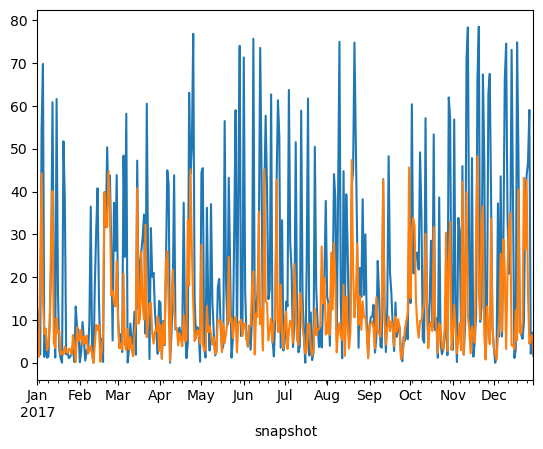

In [80]:
n.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('D').mean().plot()
n_rh24_0.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('D').mean().plot()

<Axes: xlabel='snapshot'>

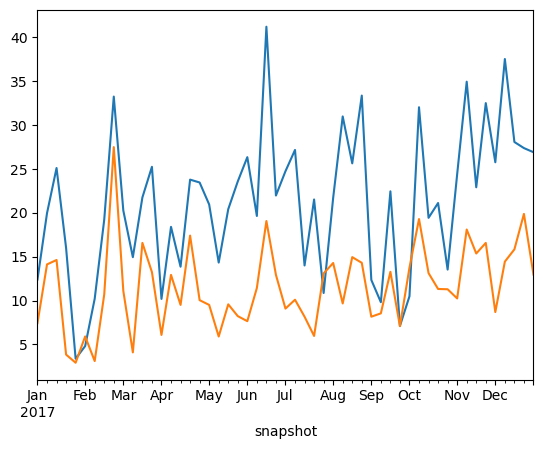

In [81]:
n.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('W').mean().plot()
n_rh24_0.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('W').mean().plot()

<Axes: xlabel='snapshot'>

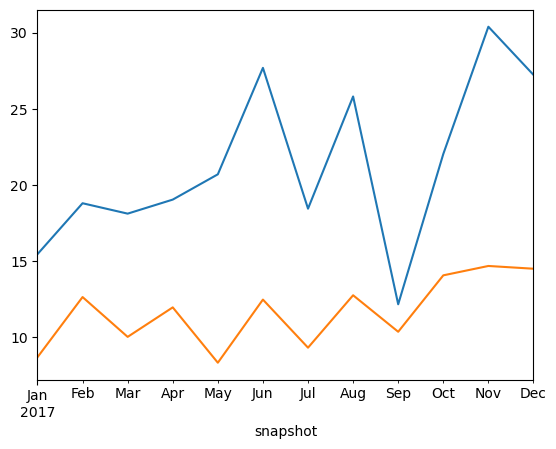

In [82]:
n.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('M').mean().plot()
n_rh24_0.stores_t.e['Rondo_Concrete_Heat_Storage'].resample('M').mean().plot()

<Axes: xlabel='snapshot'>

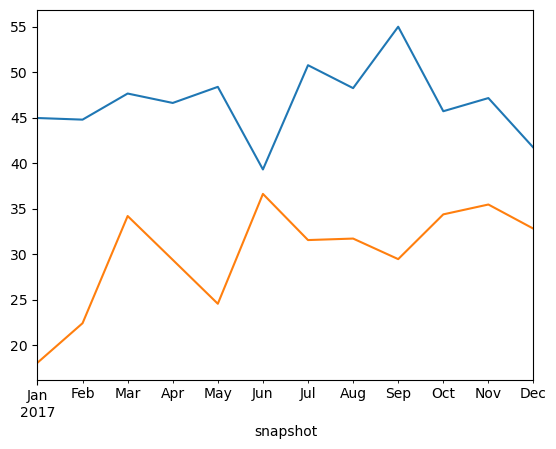

In [83]:
"Battery SOC over time (resampled)";
soc_n.resample('M').mean().plot()
soc_rh.resample('M').mean().plot()

<Axes: xlabel='snapshot'>

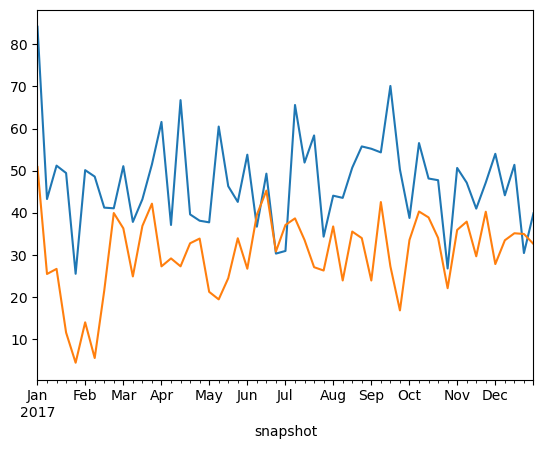

In [84]:
"Battery SOC over time (resampled)";
soc_n.resample('W').mean().plot()
soc_rh.resample('W').mean().plot()

<Axes: xlabel='snapshot'>

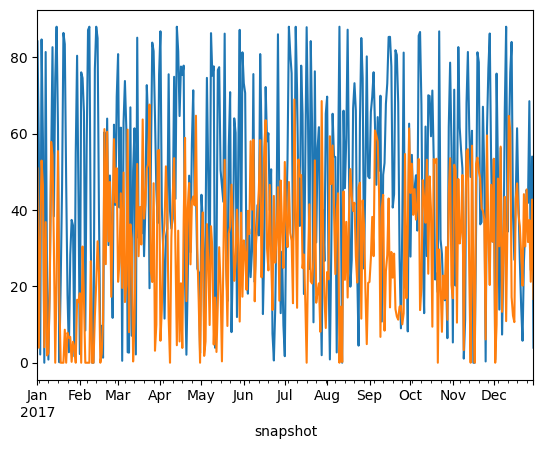

In [85]:
"Battery SOC over time (resampled)";
soc_n.resample('D').mean().plot()
soc_rh.resample('D').mean().plot()

- rondo output is pressurised (boiling pressure and temprature)
- water,steam
- steam (biogas)
- heat, steam
- water pressure tmepratuer diagram
- plot P_charge/P_discharge LDC

<!-- Steep drop at the beginning:

Both curves start at the maximum energy (~100 MWh for blue, ~90 MWh for orange).

The steep slope at the start shows that high energy levels exist only for a short period — i.e., the storage is fully charged for relatively few hours.

Gradual slope afterward:

After the initial steep drop, the curves flatten, meaning lower energy levels persist for many more hours.

This corresponds to periods where the storage is partially charged and gradually discharges over longer durations.

Comparison between curves:

The orange curve (n_rh24_0) is consistently lower than the blue curve, meaning that in this scenario the storage doesn’t reach as high energy levels or starts discharging earlier.

Both curves hit zero energy after ~5500–6000 hours, indicating the storage is empty for the remaining hours of the year -->